# Deterministic-average circuit QPINN with `torch.autograd`

This notebook is the simpler simulation counterpart of `QPINN_hyperoctahedral_chebyshev.ipynb`.  It keeps the same quantum-circuit QFM and the same screened Poisson problem, but it computes the average operator exactly and uses `torch.autograd` for the PDE residual.

## PDE definition

The physical domain is the open square

$$
\Omega=(-1,1)^2, \qquad \bar{\Omega}=[-1,1]^2,
$$

and the physical input is $x=(x_1,x_2)$.  The unknown scalar solution is $u:\bar{\Omega}\to\mathbb{R}$.  The benchmark solves the screened Poisson equation

$$
-\frac{\partial^2 u}{\partial x_1^2}(x_1,x_2)
-\frac{\partial^2 u}{\partial x_2^2}(x_1,x_2)
+\lambda u(x_1,x_2)
=q(x_1,x_2),
\qquad (x_1,x_2)\in\Omega.
$$

Here $\lambda>0$ is the screening parameter, and $q$ is the prescribed source term.  Equivalently, this is $(-\Delta+\lambda)u=q$, where

$$
\Delta u(x_1,x_2)
=\frac{\partial^2 u}{\partial x_1^2}(x_1,x_2)
+\frac{\partial^2 u}{\partial x_2^2}(x_1,x_2).
$$

The boundary condition is homogeneous Dirichlet on all four sides of the square:

$$
u(-1,x_2)=0,\quad u(1,x_2)=0 \qquad \text{for } -1\le x_2\le 1,
$$

$$
u(x_1,-1)=0,\quad u(x_1,1)=0 \qquad \text{for } -1\le x_1\le 1.
$$

The training residual for a model prediction $u_\theta$ is therefore

$$
r_\theta(x_1,x_2)
=-\frac{\partial^2 u_\theta}{\partial x_1^2}(x_1,x_2)
-\frac{\partial^2 u_\theta}{\partial x_2^2}(x_1,x_2)
+\lambda u_\theta(x_1,x_2)
-q(x_1,x_2).
$$

The neural ansatz enforces the boundary condition by construction.  It writes the final prediction as

$$
u_\theta(x_1,x_2)=B(x_1,x_2)v_\theta(x_1,x_2),
\qquad
B(x_1,x_2)=\cos\left(\frac{\pi x_1}{2}\right)\cos\left(\frac{\pi x_2}{2}\right),
$$

where $v_\theta$ is the unconstrained circuit output.  Because $B=0$ whenever $x_1=\pm 1$ or $x_2=\pm 1$, the homogeneous Dirichlet boundary condition is exact for every parameter value.  The optimized loss is therefore only the mean squared interior residual,

$$
\mathcal{L}(\theta)=\mathbb{E}_{x\in\Omega}\left[r_\theta(x_1,x_2)^2\right].
$$

The boundary mean squared value is still printed below as a diagnostic, but it is not part of the training objective.

To construct a known exact solution, define

$$
\phi_m(t)=\cos\left(\frac{m\pi t}{2}\right).
$$

The source term is

$$
q(x_1,x_2)=
\phi_1(x_1)\phi_1(x_2)
+0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right],
$$

and the corresponding analytical solution is

$$
u_\star(x_1,x_2)=
\frac{\phi_1(x_1)\phi_1(x_2)}{\lambda+\pi^2/2}
+\frac{0.3\left[\phi_1(x_1)\phi_3(x_2)+\phi_3(x_1)\phi_1(x_2)\right]}{\lambda+5\pi^2/2}.
$$

This $u_\star$ satisfies the boundary condition because $\phi_1(\pm 1)=\phi_3(\pm 1)=0$.  The denominators come from applying the differential operator explicitly: for example,

$$
\left(-\frac{\partial^2}{\partial x_1^2}-\frac{\partial^2}{\partial x_2^2}+\lambda\right)
\left[\phi_m(x_1)\phi_n(x_2)\right]
=\left(\frac{(m^2+n^2)\pi^2}{4}+\lambda\right)\phi_m(x_1)\phi_n(x_2).
$$

We compare three circuit models:

$$
f_\theta(x),
\qquad
f_\theta(\arccos x),
\qquad
(A_{B_2}f_\theta)(x).
$$

The middle model is the Kyriienko-style Chebyshev feature map: it simply feeds $u=\arccos x$ into the QFM.  As discussed around Eq. 36 of the manuscript, this direct substitution produces Chebyshev-like terms but does not by itself remove all non-polynomial components.  The last model restores the earlier working exact average operator over sign flips and coordinate permutations of the physical input $x$.

This exact-average/autograd version is not the resource-efficient hardware estimator.  Its purpose is to test the modeling effect before adding randomized encoding and parameter-shift sampling.

In [1]:
from __future__ import annotations

from collections import defaultdict
from copy import deepcopy
from itertools import permutations, product
from pathlib import Path
import os
import sys
import tempfile

import numpy as np
import torch

_MPL_CACHE = Path(tempfile.gettempdir()) / "matplotlib-cache"
_MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_CACHE))
_XDG_CACHE = Path(tempfile.gettempdir()) / "xdg-cache"
_XDG_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(_XDG_CACHE))

IS_NOTEBOOK = "ipykernel" in sys.modules
import matplotlib
if not IS_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_or_close_current_figure() -> None:
    if IS_NOTEBOOK:
        plt.show()
    else:
        plt.close()


USE_DOUBLE_PRECISION = False


def _candidate_dtype(candidate: torch.device):
    if USE_DOUBLE_PRECISION and candidate.type != "mps":
        return torch.float64
    return torch.float32


def _autograd_works(candidate: torch.device) -> bool:
    real_dt = _candidate_dtype(candidate)
    try:
        x = torch.linspace(-0.7, 0.7, 8, dtype=real_dt, device=candidate, requires_grad=True)
        y = torch.sum(torch.sin(x) ** 2 + 0.3 * torch.cos(3.0 * x))
        grad_y = torch.autograd.grad(y, x, create_graph=True)[0]
        curvature = torch.autograd.grad(grad_y.sum(), x)[0]
        if candidate.type == "cuda":
            torch.cuda.synchronize()
        return torch.isfinite(curvature).all()
    except Exception as exc:
        print(f"Skipping {candidate.type}: autograd check failed ({exc}).")
        return False


def select_accelerated_device() -> torch.device:
    candidates = []
    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))
    candidates.append(torch.device("cpu"))

    for candidate in candidates:
        if _autograd_works(candidate):
            return candidate
    return torch.device("cpu")


DEVICE = select_accelerated_device()
REAL_DTYPE = _candidate_dtype(DEVICE)
torch.set_default_dtype(REAL_DTYPE)

SEED = 71
torch.manual_seed(SEED)
np.random.seed(SEED)


def locate_paper_work_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "MSQE").exists() and cwd.name == "Paper_work":
        return cwd
    if (cwd / "Paper_work" / "MSQE").exists():
        return cwd / "Paper_work"
    for parent in cwd.parents:
        if (parent / "Paper_work" / "MSQE").exists():
            return parent / "Paper_work"
    return cwd


PAPER_WORK_DIR = locate_paper_work_dir()
FIGURE_DIR = PAPER_WORK_DIR / "MSQE" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device={DEVICE}, real dtype={REAL_DTYPE}, state representation=real/imag pair")

Using device=cuda, real dtype=torch.float32, state representation=real/imag pair


## Circuit QFM ansatz

The baseline circuit is a data re-uploading QFM.  Each upload block applies a trainable StronglyEntanglingLayer-style block followed by exponential Pauli encoding,

$$
R_X(\beta_j z_j)=\exp[-i\beta_jz_jX_j/2],
\qquad \beta_j=3^j .
$$

The unconstrained circuit output $v_\theta$ is a fixed global scale times the fixed local observable

$$
O_L=\frac{1}{n}\sum_j |0\rangle\langle 0|_j\otimes \mathbb{1}_{\bar{j}},
$$

with no trainable readout weights, output scale, or bias.  The fixed scale only sets the available output range.

The final PDE prediction is the hard-boundary output

$$
u_\theta(x)=\cos\left(\frac{\pi x_1}{2}\right)\cos\left(\frac{\pi x_2}{2}\right)v_\theta(x),
$$

so the zero Dirichlet boundary condition holds exactly before any training.

The circuit input $z$ is the physical coordinate $x$ for the Ordinary QFM and the $B_2$-symmetrized model, while the Cheb-QFM baseline uses the Chebyshev angle $u=\arccos x$.  The $B_2$-QCM restores the earlier working exact average over sign flips and coordinate permutations of the physical PDE input.

For GPU use, the exact group average is evaluated as one batched circuit call.  Instead of looping over group elements in Python, the transformed inputs are stacked into a tensor of shape `group_size * batch`, passed through `base_circuit` once, and then averaged after reshaping.  This does not change the mathematical model, but it avoids many small CUDA kernels.

In [2]:
DIM = 2
N_QUBITS = 2
N_UPLOAD_LAYERS = 2
STRONG_LAYERS_PER_BLOCK = 2

EXP_BASE = 3.0
ENCODING_SCALE = 1.0
OUTPUT_SCALE = 1.0
DIFF_GENERATOR_PER_LAYER = False
ACOS_EPS = 1.0e-6

LAMBDA = 1.0
SOURCE_MODE_COEFFICIENTS = {
    (1, 1): 1.0,
    (1, 3): 0.3,
    (3, 1): 0.3,
}

TRAINING_STEPS = 300
N_RUNS = 10
INTERIOR_BATCH = 50
BOUNDARY_BATCH = 50
LR = 1e-1
LR_DECAY = 0.99
LR_MIN = 1e-4
INTERIOR_MARGIN = 0.94
GRAD_CLIP = 5.0

EVAL_GRID_N = 41

assert DIM == 2, "This benchmark cell is written for the B_2 screened-Poisson example."
assert N_QUBITS >= DIM, "The circuit uses one encoding wire per input coordinate."


In [3]:
_CNOT_GATHER_CACHE: dict[tuple[int, int, int, str], torch.Tensor] = {}


def as_1d(theta: torch.Tensor) -> torch.Tensor:
    return theta.reshape(1) if theta.ndim == 0 else theta


def complex_pair(real: torch.Tensor, imag: torch.Tensor) -> torch.Tensor:
    return torch.stack([real.to(REAL_DTYPE), imag.to(REAL_DTYPE)], dim=-1)


def scale_complex(scale: torch.Tensor, value: torch.Tensor) -> torch.Tensor:
    return scale[..., None] * value


def multiply_complex(left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    real = left[..., 0] * right[..., 0] - left[..., 1] * right[..., 1]
    imag = left[..., 0] * right[..., 1] + left[..., 1] * right[..., 0]
    return torch.stack([real, imag], dim=-1)


def gate_from_entries(
    entry00: torch.Tensor,
    entry01: torch.Tensor,
    entry10: torch.Tensor,
    entry11: torch.Tensor,
) -> torch.Tensor:
    row0 = torch.stack([entry00, entry01], dim=1)
    row1 = torch.stack([entry10, entry11], dim=1)
    return torch.stack([row0, row1], dim=1)


def complex_exp(angle: torch.Tensor) -> torch.Tensor:
    return complex_pair(torch.cos(angle), torch.sin(angle))


def rx_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    return gate_from_entries(complex_pair(c, z), complex_pair(z, -s), complex_pair(z, -s), complex_pair(c, z))


def ry_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    return gate_from_entries(complex_pair(c, z), complex_pair(-s, z), complex_pair(s, z), complex_pair(c, z))


def rz_matrix(theta: torch.Tensor) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    return gate_from_entries(complex_pair(c, -s), complex_pair(z, z), complex_pair(z, z), complex_pair(c, s))


def rot_matrix(phi: torch.Tensor, theta: torch.Tensor, omega: torch.Tensor) -> torch.Tensor:
    phi = as_1d(phi)
    theta = as_1d(theta)
    omega = as_1d(omega)
    half_theta = 0.5 * theta
    c = torch.cos(half_theta)
    s = torch.sin(half_theta)
    half_sum = 0.5 * (phi + omega)
    half_diff = 0.5 * (phi - omega)
    return gate_from_entries(
        scale_complex(c, complex_exp(-half_sum)),
        scale_complex(-s, complex_exp(half_diff)),
        scale_complex(s, complex_exp(-half_diff)),
        scale_complex(c, complex_exp(half_sum)),
    )


def apply_single_qubit_gate(state: torch.Tensor, gate: torch.Tensor, wire: int) -> torch.Tensor:
    batch = state.shape[0]
    if gate.shape[0] == 1 and batch != 1:
        gate = gate.expand(batch, -1, -1, -1)
    tensor = state.reshape(batch, *([2] * N_QUBITS), 2)
    axis = wire + 1
    tensor = tensor.movedim(axis, -2)
    broadcast_shape = (batch,) + (1,) * (tensor.ndim - 3) + (2,)
    g00 = gate[:, 0, 0, :].reshape(broadcast_shape)
    g01 = gate[:, 0, 1, :].reshape(broadcast_shape)
    g10 = gate[:, 1, 0, :].reshape(broadcast_shape)
    g11 = gate[:, 1, 1, :].reshape(broadcast_shape)
    input0 = tensor[..., 0, :]
    input1 = tensor[..., 1, :]
    output0 = multiply_complex(g00, input0) + multiply_complex(g01, input1)
    output1 = multiply_complex(g10, input0) + multiply_complex(g11, input1)
    updated = torch.stack([output0, output1], dim=-2)
    updated = updated.movedim(-2, axis)
    return updated.reshape(batch, 2**N_QUBITS, 2)


def cnot_gather_index(n_qubits: int, control: int, target: int, device: torch.device) -> torch.Tensor:
    key = (n_qubits, control, target, device.type)
    if key in _CNOT_GATHER_CACHE:
        return _CNOT_GATHER_CACHE[key]

    gather = [0] * (2**n_qubits)
    for input_index in range(2**n_qubits):
        bits = [(input_index >> (n_qubits - 1 - q)) & 1 for q in range(n_qubits)]
        output_bits = bits[:]
        if bits[control] == 1:
            output_bits[target] ^= 1
        output_index = 0
        for bit in output_bits:
            output_index = (output_index << 1) | bit
        gather[output_index] = input_index

    tensor = torch.tensor(gather, dtype=torch.long, device=device)
    _CNOT_GATHER_CACHE[key] = tensor
    return tensor


def apply_cnot(state: torch.Tensor, control: int, target: int) -> torch.Tensor:
    gather = cnot_gather_index(N_QUBITS, control, target, state.device)
    return state[:, gather, :]


def apply_strongly_entangling_block(state: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    for sublayer in range(weights.shape[0]):
        for wire in range(N_QUBITS):
            phi, theta, omega = weights[sublayer, wire]
            state = apply_single_qubit_gate(state, rot_matrix(phi, theta, omega), wire)

        if N_QUBITS > 1:
            cnot_range = (sublayer % (N_QUBITS - 1)) + 1
            for control in range(N_QUBITS):
                target = (control + cnot_range) % N_QUBITS
                state = apply_cnot(state, control, target)
    return state


def initial_state(batch: int) -> torch.Tensor:
    state = torch.zeros(batch, 2**N_QUBITS, 2, dtype=REAL_DTYPE, device=DEVICE)
    state[:, 0, 0] = 1.0
    return state


def local_observable_values() -> torch.Tensor:
    values = []
    for basis_index in range(2**N_QUBITS):
        bits = [(basis_index >> (N_QUBITS - 1 - q)) & 1 for q in range(N_QUBITS)]
        values.append(sum(1.0 for bit in bits if bit == 0) / N_QUBITS)
    return torch.tensor(values, dtype=REAL_DTYPE, device=DEVICE)


LOCAL_OBSERVABLE_VALUES = local_observable_values()

In [4]:
SIGNFLIP_SIGNS = torch.tensor(list(product([-1.0, 1.0], repeat=DIM)), dtype=REAL_DTYPE, device=DEVICE)
B2_PERMUTATIONS = torch.tensor(list(permutations(range(DIM))), dtype=torch.long, device=DEVICE)


def map_circuit_input(x: torch.Tensor, input_map: str) -> torch.Tensor:
    if input_map == "raw":
        return x
    if input_map == "chebyshev":
        return torch.acos(torch.clamp(x, -1.0 + ACOS_EPS, 1.0 - ACOS_EPS))
    raise ValueError(f"Unknown input_map: {input_map}")


def boundary_envelope(x: torch.Tensor) -> torch.Tensor:
    return torch.prod(torch.cos(0.5 * torch.pi * x), dim=1)


def group_transformed_batch(z: torch.Tensor, group: str) -> tuple[torch.Tensor, int]:
    if group == "none":
        return z, 1

    if group == "hyperoctahedral":
        permuted = z[:, B2_PERMUTATIONS].permute(1, 0, 2)
        transformed = permuted[:, None, :, :] * SIGNFLIP_SIGNS[None, :, None, :]
        group_size = B2_PERMUTATIONS.shape[0] * SIGNFLIP_SIGNS.shape[0]
        return transformed.reshape(-1, DIM), group_size

    raise ValueError(f"Unknown group: {group}")


class ReuploadingStrongEntangleQFM(torch.nn.Module):
    def __init__(self, group: str, input_map: str, init_scale: float = 0.2, hard_boundary: bool = True):
        super().__init__()
        self.group = group
        self.input_map = input_map
        self.hard_boundary = hard_boundary
        weight_shape = (N_UPLOAD_LAYERS + 1, STRONG_LAYERS_PER_BLOCK, N_QUBITS, 3)
        self.weights = torch.nn.Parameter(
            init_scale * torch.randn(weight_shape, dtype=REAL_DTYPE, device=DEVICE)
        )
    @staticmethod
    def encoding_beta(upload: int, wire: int) -> float:
        exponent = upload * N_QUBITS + wire if DIFF_GENERATOR_PER_LAYER else wire
        return EXP_BASE ** exponent

    def base_circuit(self, z: torch.Tensor) -> torch.Tensor:
        batch = z.shape[0]
        state = initial_state(batch)

        for upload in range(N_UPLOAD_LAYERS):
            state = apply_strongly_entangling_block(state, self.weights[upload])
            for wire in range(N_QUBITS):
                coordinate = wire % DIM
                beta = self.encoding_beta(upload, wire)
                angle = ENCODING_SCALE * beta * z[:, coordinate]
                state = apply_single_qubit_gate(state, rx_matrix(angle), wire)

        state = apply_strongly_entangling_block(state, self.weights[-1])
        probabilities = torch.sum(state**2, dim=-1)
        return OUTPUT_SCALE * (probabilities @ LOCAL_OBSERVABLE_VALUES)

    def forward_from_circuit_input(self, z: torch.Tensor) -> torch.Tensor:
        transformed_z, group_size = group_transformed_batch(z, self.group)
        transformed_outputs = self.base_circuit(transformed_z)
        return transformed_outputs.reshape(group_size, z.shape[0]).mean(dim=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = map_circuit_input(x, self.input_map)
        free_output = self.forward_from_circuit_input(z)
        if self.hard_boundary:
            return boundary_envelope(x) * free_output
        return free_output


MODEL_SPECS = {
    "Ordinary QFM": {"group": "none", "input_map": "raw"},
    "Cheb-QFM": {"group": "none", "input_map": "chebyshev"},
    "$B_2$-QCM": {"group": "hyperoctahedral", "input_map": "raw"},
}


def make_models(seed: int = SEED, hard_boundary: bool = True) -> dict[str, ReuploadingStrongEntangleQFM]:
    torch.manual_seed(seed)
    reference = ReuploadingStrongEntangleQFM(group="none", input_map="raw", hard_boundary=hard_boundary)
    reference_state = deepcopy(reference.state_dict())

    models = {}
    for name, spec in MODEL_SPECS.items():
        model = ReuploadingStrongEntangleQFM(**spec, hard_boundary=hard_boundary)
        model.load_state_dict(reference_state)
        models[name] = model
    return models


def count_trainable_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

## PennyLane validation

This cell is a sanity check for the three model variants before training.  It freezes one shared random initialization, evaluates each model with the notebook's hand-written PyTorch state-vector simulator, then evaluates the same circuit with PennyLane `default.qubit`.

The PennyLane circuit uses `qml.StronglyEntanglingLayers` for the trainable blocks, followed by the same $R_X(\beta_j z_j)$ data re-uploading gates, the same fixed circuit output $\mathrm{OUTPUT\_SCALE}\,O_L$, and the same hard-boundary envelope $B(x)$.  Here $O_L=\frac{1}{n}\sum_j |0\rangle\langle 0|_j\otimes \mathbb{1}_{\bar{j}}$.  The check compares the forward value, the gradient with respect to the input coordinates, and the gradient with respect to every trainable circuit parameter.  Small nonzero differences are expected in float32.

In [5]:
try:
    import pennylane as qml
except ImportError as exc:
    raise ImportError(
        "PennyLane is required for this validation cell. "
        "Install it in the active notebook kernel with `pip install pennylane`."
    ) from exc


PL_FORWARD_TOL = 5.0e-4 if REAL_DTYPE == torch.float32 else 1.0e-8
PL_GRAD_TOL = 1.0e-3 if REAL_DTYPE == torch.float32 else 1.0e-7
PL_TEST_POINTS = torch.tensor(
    [[-0.73, -0.21], [0.17, 0.66], [0.52, -0.44]],
    dtype=REAL_DTYPE,
)

pl_device = qml.device("default.qubit", wires=N_QUBITS)
pl_wires = list(range(N_QUBITS))


def pl_encoding_beta(upload: int, wire: int) -> float:
    exponent = upload * N_QUBITS + wire if DIFF_GENERATOR_PER_LAYER else wire
    return EXP_BASE ** exponent


@qml.qnode(pl_device, interface="torch", diff_method="backprop")
def pl_base_circuit(z_single: torch.Tensor, weights: torch.Tensor):
    for upload in range(N_UPLOAD_LAYERS):
        qml.StronglyEntanglingLayers(weights[upload], wires=pl_wires)
        for wire in range(N_QUBITS):
            coordinate = wire % DIM
            angle = ENCODING_SCALE * pl_encoding_beta(upload, wire) * z_single[coordinate]
            qml.RX(angle, wires=wire)

    qml.StronglyEntanglingLayers(weights[-1], wires=pl_wires)
    return tuple(qml.expval(qml.Projector([0], wires=wire)) for wire in pl_wires)


def pl_local_observable(z_single: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    measured = pl_base_circuit(z_single, weights)
    if isinstance(measured, torch.Tensor):
        projector_values = measured.reshape(-1)
    else:
        projector_values = torch.stack([value.reshape(()) for value in measured])
    return projector_values.mean()


def pl_map_circuit_input(x: torch.Tensor, input_map: str) -> torch.Tensor:
    if input_map == "raw":
        return x
    if input_map == "chebyshev":
        return torch.acos(torch.clamp(x, -1.0 + ACOS_EPS, 1.0 - ACOS_EPS))
    raise ValueError(f"Unknown input_map: {input_map}")


def pl_group_transformed_batch(z: torch.Tensor, group: str) -> tuple[torch.Tensor, int]:
    if group == "none":
        return z, 1

    if group == "hyperoctahedral":
        signs = torch.tensor(list(product([-1.0, 1.0], repeat=DIM)), dtype=z.dtype, device=z.device)
        permutations_tensor = torch.tensor(list(permutations(range(DIM))), dtype=torch.long, device=z.device)
        permuted = z[:, permutations_tensor].permute(1, 0, 2)
        transformed = permuted[:, None, :, :] * signs[None, :, None, :]
        group_size = permutations_tensor.shape[0] * signs.shape[0]
        return transformed.reshape(-1, DIM), group_size

    raise ValueError(f"Unknown group: {group}")


def pl_model_forward(
    x: torch.Tensor,
    state: dict[str, torch.Tensor],
    group: str,
    input_map: str,
    hard_boundary: bool = True,
) -> torch.Tensor:
    z = pl_map_circuit_input(x, input_map)
    transformed_z, group_size = pl_group_transformed_batch(z, group)
    transformed_outputs = torch.stack([
        pl_local_observable(z_single, state["weights"])
        for z_single in transformed_z
    ])
    transformed_outputs = OUTPUT_SCALE * transformed_outputs
    free_output = transformed_outputs.reshape(group_size, x.shape[0]).mean(dim=0)
    if hard_boundary:
        return boundary_envelope(x) * free_output
    return free_output


def torch_forward_and_grads(model: torch.nn.Module, x_cpu: torch.Tensor):
    model.zero_grad(set_to_none=True)
    x_device = x_cpu.detach().clone().to(DEVICE).requires_grad_(True)
    output = model(x_device)
    output.sum().backward()
    grads = {
        name: parameter.grad.detach().cpu().clone()
        for name, parameter in model.named_parameters()
    }
    return output.detach().cpu(), x_device.grad.detach().cpu().clone(), grads


def pl_forward_and_grads(model: ReuploadingStrongEntangleQFM, x_cpu: torch.Tensor):
    state = {
        name: value.detach().cpu().clone().requires_grad_(True)
        for name, value in model.state_dict().items()
    }
    x = x_cpu.detach().clone().requires_grad_(True)
    output = pl_model_forward(x, state, model.group, model.input_map, hard_boundary=model.hard_boundary)
    output.sum().backward()
    grads = {name: value.grad.detach().clone() for name, value in state.items()}
    return output.detach(), x.grad.detach().clone(), grads


def max_abs_diff(left: torch.Tensor, right: torch.Tensor) -> float:
    right = right.detach().cpu().to(dtype=left.dtype)
    left = left.detach().cpu()
    return float(torch.max(torch.abs(left - right)))


validation_models = make_models(seed=SEED + 4242)
validation_rows = []

for model_name, model in validation_models.items():
    torch_output, torch_x_grad, torch_grads = torch_forward_and_grads(model, PL_TEST_POINTS)
    pl_output, pl_x_grad, pl_grads = pl_forward_and_grads(model, PL_TEST_POINTS)

    output_diff = max_abs_diff(torch_output, pl_output)
    input_grad_diff = max_abs_diff(torch_x_grad, pl_x_grad)
    parameter_grad_diff = max(
        max_abs_diff(torch_grads[name], pl_grads[name])
        for name in torch_grads
    )

    validation_rows.append((model_name, output_diff, input_grad_diff, parameter_grad_diff))

    if output_diff > PL_FORWARD_TOL:
        raise AssertionError(f"{model_name}: PennyLane forward mismatch {output_diff:.3e}")
    if input_grad_diff > PL_GRAD_TOL or parameter_grad_diff > PL_GRAD_TOL:
        raise AssertionError(
            f"{model_name}: PennyLane gradient mismatch "
            f"x={input_grad_diff:.3e}, params={parameter_grad_diff:.3e}"
        )


print("PennyLane cross-check against the torch simulator")
print(f"{'model':24s} {'forward':>12s} {'input grad':>12s} {'param grad':>12s}")
for model_name, output_diff, input_grad_diff, parameter_grad_diff in validation_rows:
    print(f"{model_name:24s} {output_diff:12.3e} {input_grad_diff:12.3e} {parameter_grad_diff:12.3e}")
print("All three model variants passed the PennyLane validation.")

PennyLane cross-check against the torch simulator
model                         forward   input grad   param grad
Ordinary QFM                1.490e-07    4.172e-07    1.788e-07
Cheb-QFM                    2.086e-07    6.557e-07    1.490e-07
$B_2$-QCM                   1.192e-07    3.576e-07    1.192e-07
All three model variants passed the PennyLane validation.


## Autograd QPINN loss

The final prediction has the form $u_\theta(x)=B(x)v_\theta(x)$, so the homogeneous Dirichlet boundary condition is built into the ansatz.  The empirical training loss is therefore the interior residual loss

$$
\mathcal L(\theta)=
\frac{1}{N_\Omega}\sum_i
\left[(-\Delta+\lambda)u_\theta(x_i)-q(x_i)\right]^2.
$$

The boundary mean squared value is still evaluated on sampled boundary points and printed as a diagnostic.  Here the Laplacian is computed by differentiating the full hard-boundary output with respect to the physical input coordinates using `torch.autograd`.

In [6]:
def phi_mode(x: torch.Tensor, mode: int) -> torch.Tensor:
    return torch.cos(0.5 * mode * torch.pi * x)


def source_term(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2)
    return value


def analytical_solution(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in SOURCE_MODE_COEFFICIENTS.items():
        eigenvalue = (0.5 * torch.pi * m1) ** 2 + (0.5 * torch.pi * m2) ** 2
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2) / (LAMBDA + eigenvalue)
    return value


def laplacian(model: torch.nn.Module, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    u = model(x_req)
    grad_u = torch.autograd.grad(u.sum(), x_req, create_graph=True)[0]

    lap = torch.zeros_like(u)
    for dim in range(DIM):
        second = torch.autograd.grad(grad_u[:, dim].sum(), x_req, create_graph=True)[0][:, dim]
        lap = lap + second
    return lap, u


def qpinn_loss(
    model: torch.nn.Module,
    interior_x: torch.Tensor,
    boundary_x: torch.Tensor,
    boundary_weight: float = 0.0,
) -> tuple[torch.Tensor, dict[str, float]]:
    lap, u_interior = laplacian(model, interior_x)
    residual = -lap + LAMBDA * u_interior - source_term(interior_x)
    residual_loss = torch.mean(residual**2)

    u_boundary = model(boundary_x)
    boundary_loss = torch.mean(u_boundary**2)
    loss = residual_loss + boundary_weight * boundary_loss

    metrics = {
        "loss": float(loss.detach().cpu()),
        "residual": float(residual_loss.detach().cpu()),
        "boundary": float(boundary_loss.detach().cpu()),
    }
    return loss, metrics


def physics_loss(
    model: torch.nn.Module,
    interior_x: torch.Tensor,
    boundary_x: torch.Tensor,
) -> tuple[torch.Tensor, dict[str, float]]:
    return qpinn_loss(model, interior_x, boundary_x, boundary_weight=0.0)

In [7]:


QPINN_DISPLAY_LABELS = {
    "Ordinary QFM": "Fourier-QPINN",
    "Cheb-QFM": "Chebyshev-QPINN",
    "$B_2$-QCM": "$B_2$-QPINN",
}
def sample_interior(batch: int) -> torch.Tensor:
    return (2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0) * INTERIOR_MARGIN


def sample_boundary(batch: int) -> torch.Tensor:
    x = 2.0 * torch.rand(batch, DIM, dtype=REAL_DTYPE, device=DEVICE) - 1.0
    sides = torch.randint(0, 2 * DIM, (batch,), device=DEVICE)
    for dim in range(DIM):
        left = sides == 2 * dim
        right = sides == 2 * dim + 1
        x[left, dim] = -1.0
        x[right, dim] = 1.0
    return x


def make_training_batches(seed: int) -> list[tuple[torch.Tensor, torch.Tensor]]:
    torch.manual_seed(seed)
    return [
        (sample_interior(INTERIOR_BATCH), sample_boundary(BOUNDARY_BATCH))
        for _ in range(TRAINING_STEPS)
    ]


def train_model(
    name: str,
    model: torch.nn.Module,
    training_batches: list[tuple[torch.Tensor, torch.Tensor]],
    run_index: int,
    loss_fn=physics_loss,
    run_count: int = N_RUNS,
    label_prefix: str | None = None,
) -> dict[str, list[float]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    min_lr_factor = LR_MIN / LR
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: max(min_lr_factor, LR_DECAY**step),
    )
    history = defaultdict(list)

    for step, (interior_x, boundary_x) in enumerate(training_batches, start=1):
        current_lr = optimizer.param_groups[0]["lr"]
        optimizer.zero_grad(set_to_none=True)
        loss, metrics = loss_fn(model, interior_x, boundary_x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        metrics["lr"] = current_lr

        for key, value in metrics.items():
            history[key].append(value)

        if run_index == 0 and (step == 1 or step % max(1, TRAINING_STEPS // 5) == 0):
            display_name = f"{label_prefix:16s} | {name:24s}" if label_prefix else f"{name:24s}"
            print(
                f"{display_name} run {run_index + 1:2d}/{run_count}, step {step:4d}/{TRAINING_STEPS}: "
                f"lr={metrics['lr']:.3e}, loss={metrics['loss']:.3e}, "
                f"residual={metrics['residual']:.3e}, boundary={metrics['boundary']:.3e}"
            )

    return dict(history)


def stack_histories(
    histories_by_key: dict,
    metric: str,
) -> dict:
    return {
        key: np.asarray([history[metric] for history in histories], dtype=float)
        for key, histories in histories_by_key.items()
    }


def summarize_history_metric(
    histories_by_key: dict,
    metric: str,
    floor: float = 1.0e-300,
) -> dict[str, dict]:
    runs = stack_histories(histories_by_key, metric)
    log_runs = {
        key: np.log(np.clip(values, floor, None))
        for key, values in runs.items()
    }
    log_mean = {key: values.mean(axis=0) for key, values in log_runs.items()}
    log_variance = {
        key: values.var(axis=0, ddof=1) if values.shape[0] > 1 else np.zeros(values.shape[1])
        for key, values in log_runs.items()
    }
    log_std = {key: np.sqrt(values) for key, values in log_variance.items()}
    return {
        "runs": runs,
        "log_runs": log_runs,
        "log_mean": log_mean,
        "log_std": log_std,
        "geo_mean": {key: np.exp(values) for key, values in log_mean.items()},
        "geo_lower": {key: np.exp(log_mean[key] - log_std[key]) for key in runs},
        "geo_upper": {key: np.exp(log_mean[key] + log_std[key]) for key in runs},
        "geo_std_factor": {key: np.exp(values) for key, values in log_std.items()},
    }


def evaluation_grid(n: int = EVAL_GRID_N) -> tuple[torch.Tensor, np.ndarray, np.ndarray]:
    axis = torch.linspace(-1.0, 1.0, n, dtype=REAL_DTYPE, device=DEVICE)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack([x1.reshape(-1), x2.reshape(-1)], dim=1)
    return points, x1.detach().cpu().numpy(), x2.detach().cpu().numpy()


@torch.no_grad()
def evaluate_model(model: torch.nn.Module, points: torch.Tensor) -> torch.Tensor:
    return model(points).detach()


def relative_l2_error(pred: torch.Tensor, target: torch.Tensor) -> float:
    return float(torch.linalg.norm(pred - target).cpu() / torch.linalg.norm(target).cpu())


def symmetry_defects(model: torch.nn.Module, points: torch.Tensor) -> dict[str, float]:
    with torch.no_grad():
        base = model(points)

        z = map_circuit_input(points, model.input_map)
        model_input_sign_flip = model.forward_from_circuit_input(
            z * torch.tensor([-1.0, 1.0], dtype=REAL_DTYPE, device=DEVICE)
        )

        permutation = model(points[:, [1, 0]])
        physical_sign_flip = model(points * torch.tensor([-1.0, 1.0], dtype=REAL_DTYPE, device=DEVICE))

    return {
        "model_input_sign_flip_mse": float(torch.mean((base - model_input_sign_flip) ** 2).cpu()),
        "permutation_mse": float(torch.mean((base - permutation) ** 2).cpu()),
        "physical_evenness_mse": float(torch.mean((base - physical_sign_flip) ** 2).cpu()),
    }

TRAINING_CHECKPOINT_DIR = FIGURE_DIR / "training_checkpoints"
TRAINING_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_CHECKPOINT_LATEST_PATH = TRAINING_CHECKPOINT_DIR / "qpinn_boundary_constraint_latest.pt"


def state_dict_to_cpu(model: torch.nn.Module) -> dict[str, torch.Tensor]:
    return {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }


def atomic_torch_save(payload: dict, path: Path) -> None:
    tmp_path = path.with_name(path.name + ".tmp")
    torch.save(payload, tmp_path)
    tmp_path.replace(path)


def load_training_checkpoint(path: Path = TRAINING_CHECKPOINT_LATEST_PATH) -> dict:
    return torch.load(path, map_location="cpu", weights_only=False)


In [ ]:
SOFT_BOUNDARY_WEIGHT = 10.0  # Set this to the old BOUNDARY_WEIGHT value when reproducing a prior soft run.
COMPARISON_LABELS = ("Hard constraint", "Soft constraint")
COMPARISON_CONSTRAINT_SLUGS = {
    "Hard constraint": "hard",
    "Soft constraint": "soft",
}
COMPARISON_MODEL_SLUGS = {
    "Ordinary QFM": "ordinary_qfm",
    "Cheb-QFM": "cheb_qfm",
    "$B_2$-QCM": "b2_qcm",
}
LOSS_COLORS = {
    "Ordinary QFM": "#1f77b4",
    "Cheb-QFM": "#7b2cbf",
    "$B_2$-QCM": "#d62728",
}
COMPARISON_SETUPS = {
    "Hard constraint": {"hard_boundary": True, "boundary_weight": 0.0},
    "Soft constraint": {"hard_boundary": False, "boundary_weight": SOFT_BOUNDARY_WEIGHT},
}
def make_boundary_weighted_loss(boundary_weight: float):
    def loss_fn(
        model: torch.nn.Module,
        interior_x: torch.Tensor,
        boundary_x: torch.Tensor,
    ) -> tuple[torch.Tensor, dict[str, float]]:
        return qpinn_loss(model, interior_x, boundary_x, boundary_weight=boundary_weight)

    return loss_fn


def save_training_checkpoint(completed_runs: int) -> Path:
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    checkpoint_path = TRAINING_CHECKPOINT_DIR / f"qpinn_boundary_constraint_run_{completed_runs:03d}.pt"
    payload = {
        "completed_runs": completed_runs,
        "requested_runs": N_RUNS,
        "run_metadata": list(run_metadata),
        "constraint_labels": list(COMPARISON_LABELS),
        "model_names": list(MODEL_SPECS.keys()),
        "comparison_setups": COMPARISON_SETUPS,
        "comparison_constraint_slugs": COMPARISON_CONSTRAINT_SLUGS,
        "comparison_model_slugs": COMPARISON_MODEL_SLUGS,
        "config": {
            "seed": SEED,
            "dim": DIM,
            "n_qubits": N_QUBITS,
            "n_upload_layers": N_UPLOAD_LAYERS,
            "strong_layers_per_block": STRONG_LAYERS_PER_BLOCK,
            "training_steps": TRAINING_STEPS,
            "interior_batch": INTERIOR_BATCH,
            "boundary_batch": BOUNDARY_BATCH,
            "lr": LR,
            "lr_decay": LR_DECAY,
            "lr_min": LR_MIN,
            "interior_margin": INTERIOR_MARGIN,
            "grad_clip": GRAD_CLIP,
            "lambda": LAMBDA,
            "source_mode_coefficients": SOURCE_MODE_COEFFICIENTS,
            "soft_boundary_weight": SOFT_BOUNDARY_WEIGHT,
            "output_scale": OUTPUT_SCALE,
        },
        "environment": {
            "device": str(DEVICE),
            "real_dtype": str(REAL_DTYPE),
            "torch_version": torch.__version__,
            "torch_cuda_version": torch.version.cuda,
            "cuda_device_name": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
        },
        "all_histories": all_histories,
        "final_losses": final_losses,
        "comparison_histories": comparison_histories,
        "comparison_final_residuals": comparison_final_residuals,
        "comparison_final_objectives": comparison_final_objectives,
        "hard_model_state_dicts_by_run": [
            {model_name: state_dict_to_cpu(model) for model_name, model in run_models.items()}
            for run_models in all_models_by_run
        ],
        "comparison_model_state_dicts_by_run": [
            {key: state_dict_to_cpu(model) for key, model in run_models.items()}
            for run_models in comparison_models_by_run
        ],
    }
    atomic_torch_save(payload, checkpoint_path)
    atomic_torch_save(payload, TRAINING_CHECKPOINT_LATEST_PATH)
    return checkpoint_path


comparison_loss_fns = {
    constraint_label: make_boundary_weighted_loss(setup["boundary_weight"])
    for constraint_label, setup in COMPARISON_SETUPS.items()
}

all_histories = {model_name: [] for model_name in MODEL_SPECS}
all_models_by_run = []
final_losses = {model_name: [] for model_name in MODEL_SPECS}

comparison_histories = {
    (constraint_label, model_name): []
    for constraint_label in COMPARISON_LABELS
    for model_name in MODEL_SPECS
}
comparison_final_residuals = {key: [] for key in comparison_histories}
comparison_final_objectives = {key: [] for key in comparison_histories}
comparison_models_by_run = []
run_metadata = []
run_checkpoint_paths = []

for run_index in range(N_RUNS):
    init_seed = SEED + 1000 * run_index
    batch_seed = SEED + 1000 * run_index + 137
    print(f"\n=== Run {run_index + 1}/{N_RUNS} | init_seed={init_seed}, batch_seed={batch_seed} ===")

    training_batches = make_training_batches(seed=batch_seed)
    models_by_constraint = {
        constraint_label: make_models(seed=init_seed, hard_boundary=setup["hard_boundary"])
        for constraint_label, setup in COMPARISON_SETUPS.items()
    }

    if run_index == 0:
        print("\nTrainable parameter counts (same for hard and soft constraints):")
        for model_name, model in models_by_constraint["Hard constraint"].items():
            print(f"  {model_name:24s}: {count_trainable_parameters(model):d}")

    run_models = {}
    for constraint_label in COMPARISON_LABELS:
        for model_name, model in models_by_constraint[constraint_label].items():
            history = train_model(
                model_name,
                model,
                training_batches,
                run_index,
                loss_fn=comparison_loss_fns[constraint_label],
                run_count=N_RUNS,
                label_prefix=constraint_label,
            )
            key = (constraint_label, model_name)
            comparison_histories[key].append(history)
            comparison_final_residuals[key].append(history["residual"][-1])
            comparison_final_objectives[key].append(history["loss"][-1])
            run_models[key] = model

            if constraint_label == "Hard constraint":
                all_histories[model_name].append(history)
                final_losses[model_name].append(history["loss"][-1])

    all_models_by_run.append(models_by_constraint["Hard constraint"])
    comparison_models_by_run.append(run_models)
    run_metadata.append({"run_index": run_index, "init_seed": init_seed, "batch_seed": batch_seed})

    checkpoint_path = save_training_checkpoint(completed_runs=run_index + 1)
    run_checkpoint_paths.append(checkpoint_path)
    print(f"saved completed-run checkpoint: {checkpoint_path}")
    print(f"latest checkpoint alias: {TRAINING_CHECKPOINT_LATEST_PATH}")


loss_summary = summarize_history_metric(all_histories, "loss")
loss_runs = loss_summary["runs"]
loss_geo_mean = loss_summary["geo_mean"]
loss_geo_lower = loss_summary["geo_lower"]
loss_geo_upper = loss_summary["geo_upper"]
loss_geo_std_factor = loss_summary["geo_std_factor"]

comparison_residual_summary = summarize_history_metric(comparison_histories, "residual")
comparison_objective_summary = summarize_history_metric(comparison_histories, "loss")
comparison_metric_runs = comparison_residual_summary["runs"]
comparison_residual_geo_mean = comparison_residual_summary["geo_mean"]
comparison_residual_geo_lower = comparison_residual_summary["geo_lower"]
comparison_residual_geo_upper = comparison_residual_summary["geo_upper"]
comparison_objective_geo_mean = comparison_objective_summary["geo_mean"]
comparison_objective_geo_lower = comparison_objective_summary["geo_lower"]
comparison_objective_geo_upper = comparison_objective_summary["geo_upper"]

representative_run_index = {
    model_name: int(np.argmin(losses))
    for model_name, losses in final_losses.items()
}

models = {
    model_name: all_models_by_run[run_index][model_name]
    for model_name, run_index in representative_run_index.items()
}

histories = {
    model_name: all_histories[model_name][run_index]
    for model_name, run_index in representative_run_index.items()
}

comparison_selection_values = {
    key: comparison_final_objectives[key] if key[0] == "Soft constraint" else comparison_final_residuals[key]
    for key in comparison_histories
}
comparison_representative_run_index = {
    key: int(np.argmin(values))
    for key, values in comparison_selection_values.items()
}
comparison_models = {
    key: comparison_models_by_run[run_index][key]
    for key, run_index in comparison_representative_run_index.items()
}

print("\nRepresentative hard-constraint runs selected by lowest final training loss:")
for model_name, run_index in representative_run_index.items():
    print(f"  {model_name:24s}: run {run_index + 1}/{N_RUNS}, final loss={final_losses[model_name][run_index]:.3e}")

print("\nRepresentative boundary-comparison runs:")
for constraint_label in COMPARISON_LABELS:
    for model_name in MODEL_SPECS:
        key = (constraint_label, model_name)
        run_index = comparison_representative_run_index[key]
        print(
            f"  {constraint_label:16s} | {model_name:24s}: "
            f"run {run_index + 1}/{N_RUNS}, "
            f"residual={comparison_final_residuals[key][run_index]:.3e}, "
            f"objective={comparison_final_objectives[key][run_index]:.3e}"
        )


In [ ]:
symmetry_points, _, _ = evaluation_grid()
symmetry = {}

for model_name, model in models.items():
    symmetry[model_name] = symmetry_defects(model, symmetry_points)

print("Symmetry diagnostics")
for model_name, defects in symmetry.items():
    print(
        f"  {model_name:24s}: model-input sign-flip MSE={defects['model_input_sign_flip_mse']:.3e}, "
        f"permutation MSE={defects['permutation_mse']:.3e}, "
        f"physical x sign-flip MSE={defects['physical_evenness_mse']:.3e}"
    )

In [ ]:
labels = list(symmetry.keys())
model_sign_values = [symmetry[name]["model_input_sign_flip_mse"] for name in labels]
perm_values = [symmetry[name]["permutation_mse"] for name in labels]
physical_sign_values = [symmetry[name]["physical_evenness_mse"] for name in labels]

xpos = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8.4, 4.4))
plt.bar(xpos - width, model_sign_values, width, label="model-input sign flip")
plt.bar(xpos, perm_values, width, label="coordinate permutation")
plt.bar(xpos + width, physical_sign_values, width, label="physical x sign flip")
plt.yscale("log")
plt.xticks(xpos, labels, rotation=15, ha="right")
plt.ylabel("mean squared defect")
plt.title("Symmetry diagnostics")
plt.legend(frameon=False)
plt.tight_layout()
symmetry_path = FIGURE_DIR / "qpinn_b2_autograd_symmetry_metrics.png"
plt.savefig(symmetry_path, dpi=220)
show_or_close_current_figure()
print(f"saved {symmetry_path}")

## Hard vs soft boundary comparison

The training cell above fits the hard Dirichlet ansatz and the matched soft-constraint baseline in one pass.  The hard setup uses $u_\theta(x)=B(x)v_\theta(x)$ and optimizes the residual loss; the soft setup directly outputs $u_\theta$ and optimizes residual plus a boundary penalty.  The plots below keep hard and soft results in separate figures so each y-axis matches the optimized quantity.


In [ ]:
comparison_steps = np.arange(1, TRAINING_STEPS + 1)
COMPARISON_LOSS_PLOT_CONFIGS = {
    "Hard constraint": {
        "title": "Hard constraint",
        "ylabel": "Residual loss",
        "mean": comparison_residual_geo_mean,
        "lower": comparison_residual_geo_lower,
        "upper": comparison_residual_geo_upper,
        "filename": "qpinn_boundary_hard_constraint_residual_loss.png",
    },
    "Soft constraint": {
        "title": "Soft constraint",
        "ylabel": "Total loss",
        "mean": comparison_objective_geo_mean,
        "lower": comparison_objective_geo_lower,
        "upper": comparison_objective_geo_upper,
        "filename": "qpinn_boundary_soft_constraint_total_loss.png",
    },
}


def plot_boundary_constraint_loss(constraint_label: str) -> Path:
    config = COMPARISON_LOSS_PLOT_CONFIGS[constraint_label]
    fig, ax = plt.subplots(figsize=(8.6, 5.8), dpi=220)

    for model_name in MODEL_SPECS:
        key = (constraint_label, model_name)
        mean = config["mean"][key]
        lower = config["lower"][key]
        upper = config["upper"][key]
        color = LOSS_COLORS[model_name]

        ax.semilogy(
            comparison_steps,
            mean,
            label=QPINN_DISPLAY_LABELS.get(model_name, model_name),
            color=color,
            linewidth=3.0,
        )
        if N_RUNS > 1:
            ax.fill_between(comparison_steps, lower, upper, color=color, alpha=0.15, linewidth=0)

    ax.set_title(config["title"], fontsize=26, pad=12)
    ax.set_xlabel("Training step", fontsize=24, labelpad=10)
    ax.set_ylabel(config["ylabel"], fontsize=24, labelpad=10)
    ax.tick_params(axis="both", which="major", labelsize=18, width=1.1, length=5)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)
    ax.grid(True, which="major", alpha=0.24, linewidth=1.0)
    ax.grid(True, which="minor", alpha=0.10, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.legend(frameon=False, loc="best", fontsize=21, handlelength=2.4)
    fig.tight_layout()

    path = FIGURE_DIR / config["filename"]
    fig.savefig(path, dpi=260, bbox_inches="tight")
    show_or_close_current_figure()
    return path


boundary_loss_paths = {
    constraint_label: plot_boundary_constraint_loss(constraint_label)
    for constraint_label in COMPARISON_LABELS
}
for constraint_label, path in boundary_loss_paths.items():
    print(f"saved {constraint_label}: {path}")


In [ ]:
comparison_grid_points, comparison_grid_x1, comparison_grid_x2 = evaluation_grid()
comparison_target = analytical_solution(comparison_grid_points).detach()
comparison_target_grid = comparison_target.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)

comparison_predictions = {}
comparison_errors = {}
comparison_prediction_stats = {}

for key, model in comparison_models.items():
    pred = evaluate_model(model, comparison_grid_points)
    pred_grid = pred.cpu().numpy().reshape(EVAL_GRID_N, EVAL_GRID_N)
    comparison_predictions[key] = pred_grid
    comparison_errors[key] = relative_l2_error(pred, comparison_target)
    comparison_prediction_stats[key] = {
        "min": float(pred.min().cpu()),
        "max": float(pred.max().cpu()),
        "std": float(pred.std().cpu()),
    }

print("Boundary-constraint comparison prediction ranges and errors")
for constraint_label in COMPARISON_LABELS:
    for model_name in MODEL_SPECS:
        key = (constraint_label, model_name)
        stats = comparison_prediction_stats[key]
        print(
            f"  {constraint_label:16s} | {model_name:24s}: "
            f"error={comparison_errors[key]:.4e}, "
            f"min={stats['min']:.3e}, max={stats['max']:.3e}, std={stats['std']:.3e}"
        )


def plot_boundary_constraint_solution(constraint_label: str) -> Path:
    panels = [("Analytical", comparison_target_grid)]
    for model_name in MODEL_SPECS:
        key = (constraint_label, model_name)
        title = f"{QPINN_DISPLAY_LABELS.get(model_name, model_name)}\nerror={comparison_errors[key]:.2e}"
        panels.append((title, comparison_predictions[key]))

    vmin = min(np.min(panel) for _, panel in panels)
    vmax = max(np.max(panel) for _, panel in panels)

    fig, axes = plt.subplots(2, 2, figsize=(10.6, 8.5), constrained_layout=True)
    last_image = None

    for ax, (title, values) in zip(axes.ravel(), panels):
        last_image = ax.contourf(
            comparison_grid_x1,
            comparison_grid_x2,
            values,
            levels=56,
            cmap="Blues",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=18, pad=9)
        ax.set_xlabel("$x_1$", fontsize=18, labelpad=3)
        ax.set_ylabel("$x_2$", fontsize=18, labelpad=3)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.tick_params(axis="both", labelsize=14, width=1.0, length=4)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    fig.suptitle(constraint_label, fontsize=22)
    colorbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.84, pad=0.03)
    colorbar.set_label("$u(x_1,x_2)$", fontsize=18, labelpad=10)
    colorbar.ax.tick_params(labelsize=14, width=1.0, length=4)

    slug = COMPARISON_CONSTRAINT_SLUGS[constraint_label]
    path = FIGURE_DIR / f"qpinn_boundary_{slug}_constraint_solution_comparison.png"
    fig.savefig(path, dpi=240, bbox_inches="tight")
    show_or_close_current_figure()
    return path


boundary_solution_paths = {
    constraint_label: plot_boundary_constraint_solution(constraint_label)
    for constraint_label in COMPARISON_LABELS
}
for constraint_label, path in boundary_solution_paths.items():
    print(f"saved {constraint_label}: {path}")


In [ ]:
combined_solution_columns = ["Analytical", *MODEL_SPECS.keys()]
combined_solution_values = [comparison_target_grid]
for constraint_label in COMPARISON_LABELS:
    for model_name in MODEL_SPECS:
        combined_solution_values.append(comparison_predictions[(constraint_label, model_name)])

combined_vmin = min(float(np.min(values)) for values in combined_solution_values)
combined_vmax = max(float(np.max(values)) for values in combined_solution_values)

fig, axes = plt.subplots(
    len(COMPARISON_LABELS),
    len(combined_solution_columns),
    figsize=(18.0, 7.2),
    constrained_layout=True,
    squeeze=False,
)
last_image = None

for row, constraint_label in enumerate(COMPARISON_LABELS):
    for col, column_label in enumerate(combined_solution_columns):
        ax = axes[row, col]
        if column_label == "Analytical":
            values = comparison_target_grid
            title = "Analytical"
        else:
            key = (constraint_label, column_label)
            values = comparison_predictions[key]
            title = f"{QPINN_DISPLAY_LABELS.get(column_label, column_label)}\nerror={comparison_errors[key]:.2e}"

        last_image = ax.contourf(
            comparison_grid_x1,
            comparison_grid_x2,
            values,
            levels=56,
            cmap="Plasma",
            vmin=combined_vmin,
            vmax=combined_vmax,
        )
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=18, pad=9)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.tick_params(axis="both", labelsize=12, width=1.0, length=4)
        if row == len(COMPARISON_LABELS) - 1:
            ax.set_xlabel("$x_1$", fontsize=14, labelpad=2)
        if col == 0:
            ax.set_ylabel(f"{constraint_label}\n$x_2$", fontsize=18, labelpad=7)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

fig.suptitle("Hard vs soft constraint", fontsize=24)
colorbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015)
colorbar.set_label("$u(x_1,x_2)$", fontsize=18, labelpad=8)
colorbar.ax.tick_params(labelsize=12, width=1.0, length=4)

combined_boundary_solution_path = FIGURE_DIR / "qpinn_boundary_constraint_solution_comparison_combined.png"
fig.savefig(combined_boundary_solution_path, dpi=240, bbox_inches="tight")
show_or_close_current_figure()
print(f"saved combined boundary solution comparison: {combined_boundary_solution_path}")


In [ ]:
boundary_comparison_data_path = FIGURE_DIR / "qpinn_boundary_constraint_comparison_data.npz"

comparison_data = {
    "constraint_labels": np.asarray(COMPARISON_LABELS, dtype=str),
    "model_names": np.asarray(list(MODEL_SPECS.keys()), dtype=str),
    "comparison_steps": np.arange(1, TRAINING_STEPS + 1),
    "grid_x1": comparison_grid_x1,
    "grid_x2": comparison_grid_x2,
    "target_grid": comparison_target_grid,
    "training_steps": np.asarray(TRAINING_STEPS),
    "comparison_n_runs": np.asarray(N_RUNS),
    "soft_boundary_weight": np.asarray(SOFT_BOUNDARY_WEIGHT),
}

for constraint_label in COMPARISON_LABELS:
    constraint_slug = COMPARISON_CONSTRAINT_SLUGS[constraint_label]
    for model_name in MODEL_SPECS:
        model_slug = COMPARISON_MODEL_SLUGS[model_name]
        prefix = f"{constraint_slug}_{model_slug}"
        key = (constraint_label, model_name)
        histories_for_key = comparison_histories[key]

        comparison_data[f"{prefix}_objective_runs"] = np.asarray(
            [history["loss"] for history in histories_for_key], dtype=float
        )
        comparison_data[f"{prefix}_residual_runs"] = np.asarray(
            [history["residual"] for history in histories_for_key], dtype=float
        )
        comparison_data[f"{prefix}_boundary_runs"] = np.asarray(
            [history["boundary"] for history in histories_for_key], dtype=float
        )
        comparison_data[f"{prefix}_residual_geo_mean"] = comparison_residual_geo_mean[key]
        comparison_data[f"{prefix}_residual_geo_lower"] = comparison_residual_geo_lower[key]
        comparison_data[f"{prefix}_residual_geo_upper"] = comparison_residual_geo_upper[key]
        comparison_data[f"{prefix}_objective_geo_mean"] = comparison_objective_geo_mean[key]
        comparison_data[f"{prefix}_objective_geo_lower"] = comparison_objective_geo_lower[key]
        comparison_data[f"{prefix}_objective_geo_upper"] = comparison_objective_geo_upper[key]
        comparison_data[f"{prefix}_prediction_grid"] = comparison_predictions[key]
        comparison_data[f"{prefix}_error"] = np.asarray(comparison_errors[key])
        comparison_data[f"{prefix}_representative_run_index"] = np.asarray(
            comparison_representative_run_index[key]
        )

np.savez_compressed(boundary_comparison_data_path, **comparison_data)
print(f"saved plot-ready boundary comparison data: {boundary_comparison_data_path}")

## Reload saved comparison data

If the kernel stops after training, this cell recreates the combined hard/soft solution figure directly from `qpinn_boundary_constraint_comparison_data.npz`.  It does not rebuild the models and does not use CUDA.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def locate_saved_figure_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "Paper_work" / "MSQE" / "figures",
        cwd / "MSQE" / "figures",
        cwd,
    ]
    for parent in [cwd, *cwd.parents]:
        candidates.extend([
            parent / "Paper_work" / "MSQE" / "figures",
            parent / "MSQE" / "figures",
        ])
    for candidate in candidates:
        if (candidate / "qpinn_boundary_constraint_comparison_data.npz").exists():
            return candidate
    raise FileNotFoundError("Could not find qpinn_boundary_constraint_comparison_data.npz")


def show_or_close_saved_figure() -> None:
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()


saved_figure_dir = locate_saved_figure_dir()
saved_comparison_data_path = saved_figure_dir / "qpinn_boundary_constraint_comparison_data.npz"
saved_data = np.load(saved_comparison_data_path)

saved_constraint_labels = [str(value) for value in saved_data["constraint_labels"]]
saved_model_names = [str(value) for value in saved_data["model_names"]]
saved_constraint_slugs = {"Hard constraint": "hard", "Soft constraint": "soft"}
QPINN_DISPLAY_LABELS = {
    "Ordinary QFM": "Fourier-QPINN",
    "Cheb-QFM": "Chebyshev-QPINN",
    "$B_2$-QCM": "$B_2$-QPINN",
}

saved_model_slugs = {
    "Ordinary QFM": "ordinary_qfm",
    "Cheb-QFM": "cheb_qfm",
    "$B_2$-QCM": "b2_qcm",
}

saved_grid_x1 = saved_data["grid_x1"]
saved_grid_x2 = saved_data["grid_x2"]
saved_target_grid = saved_data["target_grid"]
saved_predictions = {}
saved_errors = {}

for constraint_label in saved_constraint_labels:
    constraint_slug = saved_constraint_slugs[constraint_label]
    for model_name in saved_model_names:
        model_slug = saved_model_slugs[model_name]
        key = (constraint_label, model_name)
        prefix = f"{constraint_slug}_{model_slug}"
        saved_predictions[key] = saved_data[f"{prefix}_prediction_grid"]
        saved_errors[key] = float(saved_data[f"{prefix}_error"])

saved_combined_values = [saved_target_grid, *saved_predictions.values()]
saved_combined_vmin = min(float(np.min(values)) for values in saved_combined_values)
saved_combined_vmax = max(float(np.max(values)) for values in saved_combined_values)

fig, axes = plt.subplots(
    len(saved_constraint_labels),
    1 + len(saved_model_names),
    figsize=(18.0, 7.2),
    constrained_layout=True,
    squeeze=False,
)
last_image = None

for row, constraint_label in enumerate(saved_constraint_labels):
    for col, title_name in enumerate(["Analytical", *saved_model_names]):
        ax = axes[row, col]
        if title_name == "Analytical":
            values = saved_target_grid
            title = "Analytical"
        else:
            key = (constraint_label, title_name)
            values = saved_predictions[key]
            title = f"{QPINN_DISPLAY_LABELS.get(title_name, title_name)}\nerror={saved_errors[key]:.2e}"

        last_image = ax.contourf(
            saved_grid_x1,
            saved_grid_x2,
            values,
            levels=56,
            cmap="plasma",
            vmin=saved_combined_vmin,
            vmax=saved_combined_vmax,
        )
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=18, pad=9)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.tick_params(axis="both", labelsize=12, width=1.0, length=4)
        if row == len(saved_constraint_labels) - 1:
            ax.set_xlabel("$x_1$", fontsize=14, labelpad=2)
        if col == 0:
            ax.set_ylabel(f"{constraint_label}\n$x_2$", fontsize=18, labelpad=7)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

fig.suptitle("Hard vs soft constraint", fontsize=24)
colorbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015)
colorbar.set_label("$u(x_1,x_2)$", fontsize=18, labelpad=8)
colorbar.ax.tick_params(labelsize=12, width=1.0, length=4)

saved_combined_boundary_solution_path = saved_figure_dir / "qpinn_boundary_constraint_solution_comparison_combined.png"
fig.savefig(saved_combined_boundary_solution_path, dpi=240, bbox_inches="tight")
show_or_close_saved_figure()

print(f"loaded plot-ready data: {saved_comparison_data_path}")
print(f"training_steps={int(saved_data['training_steps'])}, n_runs={int(saved_data['comparison_n_runs'])}")
print(f"saved combined boundary solution comparison: {saved_combined_boundary_solution_path}")


## Fully connected PINN baseline

This cell trains matched hard- and soft-constraint fully connected PINNs, reads the saved QPINN data from disk, and redraws the hard/soft loss figures plus the combined solution comparison with an added Fully connected PINN column.


In [ ]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import torch
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


QPINN_DISPLAY_LABELS = {
    "Ordinary QFM": "Fourier-QPINN",
    "Cheb-QFM": "Chebyshev-QPINN",
    "$B_2$-QCM": "$B_2$-QPINN",
}
QPINN_MODEL_SLUGS = {
    "Ordinary QFM": "ordinary_qfm",
    "Cheb-QFM": "cheb_qfm",
    "$B_2$-QCM": "b2_qcm",
}
PINN_DISPLAY_LABEL = "Fully connected PINN"
PINN_MODEL_SLUG = "fc_pinn"
PINN_CONSTRAINT_SLUGS = {"Hard constraint": "hard", "Soft constraint": "soft"}
PINN_COLORS = {
    "Fourier-QPINN": "#1f77b4",
    "Chebyshev-QPINN": "#7b2cbf",
    "$B_2$-QPINN": "#d62728",
    PINN_DISPLAY_LABEL: "#00A6A6",
}


def pinn_locate_qpinn_data_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    if "FIGURE_DIR" in globals():
        candidates.append(Path(FIGURE_DIR))
    candidates.extend([cwd / "Paper_work" / "MSQE" / "figures", cwd / "MSQE" / "figures", cwd])
    for parent in [cwd, *cwd.parents]:
        candidates.extend([parent / "Paper_work" / "MSQE" / "figures", parent / "MSQE" / "figures"])
    seen = set()
    for directory in candidates:
        directory = directory.resolve()
        if directory in seen:
            continue
        seen.add(directory)
        data_path = directory / "qpinn_boundary_constraint_comparison_data.npz"
        if data_path.exists():
            return data_path
    raise FileNotFoundError("Could not find qpinn_boundary_constraint_comparison_data.npz")


def pinn_show_or_close_current_figure() -> None:
    if "show_or_close_current_figure" in globals():
        show_or_close_current_figure()
    elif "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()


qpinn_data_path = pinn_locate_qpinn_data_path()
qpinn_data = np.load(qpinn_data_path)
PINN_FIGURE_DIR = Path(globals().get("FIGURE_DIR", qpinn_data_path.parent))
PINN_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PINN_DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
PINN_REAL_DTYPE = globals().get("REAL_DTYPE", torch.float32)
PINN_DIM = int(globals().get("DIM", 2))
PINN_TRAINING_STEPS = int(globals().get("TRAINING_STEPS", int(qpinn_data["training_steps"])))
PINN_N_RUNS = int(globals().get("N_RUNS", 10))
PINN_INTERIOR_BATCH = int(globals().get("INTERIOR_BATCH", 50))
PINN_BOUNDARY_BATCH = int(globals().get("BOUNDARY_BATCH", 50))
PINN_LR = float(globals().get("LR", 1.0e-1))
PINN_LR_DECAY = float(globals().get("LR_DECAY", 0.99))
PINN_LR_MIN = float(globals().get("LR_MIN", 1.0e-4))
PINN_INTERIOR_MARGIN = float(globals().get("INTERIOR_MARGIN", 0.94))
PINN_GRAD_CLIP = float(globals().get("GRAD_CLIP", 5.0))
PINN_LAMBDA = float(globals().get("LAMBDA", 1.0))
PINN_SEED = int(globals().get("SEED", 71))
PINN_SOURCE_MODE_COEFFICIENTS = dict(globals().get(
    "SOURCE_MODE_COEFFICIENTS",
    {(1, 1): 1.0, (1, 3): 0.3, (3, 1): 0.3},
))
PINN_SOFT_BOUNDARY_WEIGHT = float(globals().get(
    "SOFT_BOUNDARY_WEIGHT",
    float(qpinn_data["soft_boundary_weight"]) if "soft_boundary_weight" in qpinn_data.files else 10.0,
))
PINN_HIDDEN_LAYERS = (8, 8)
PINN_LABELS = ("Hard constraint", "Soft constraint")

PINN_CHECKPOINT_DIR = PINN_FIGURE_DIR / "pinn_training_checkpoints"
PINN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PINN_CHECKPOINT_LATEST_PATH = PINN_CHECKPOINT_DIR / "pinn_boundary_constraint_latest.pt"


def pinn_phi_mode(x: torch.Tensor, mode: int) -> torch.Tensor:
    return torch.cos(0.5 * mode * torch.pi * x)


def pinn_source_term(x: torch.Tensor) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in PINN_SOURCE_MODE_COEFFICIENTS.items():
        value = value + coefficient * pinn_phi_mode(x[:, 0], m1) * pinn_phi_mode(x[:, 1], m2)
    return value


def pinn_boundary_envelope(x: torch.Tensor) -> torch.Tensor:
    return torch.prod(torch.cos(0.5 * torch.pi * x), dim=1)


class FullyConnectedPINN(torch.nn.Module):
    def __init__(self, hard_boundary: bool):
        super().__init__()
        self.hard_boundary = hard_boundary
        layers = []
        in_features = PINN_DIM
        for out_features in PINN_HIDDEN_LAYERS:
            layers.append(torch.nn.Linear(in_features, out_features))
            layers.append(torch.nn.Tanh())
            in_features = out_features
        layers.append(torch.nn.Linear(in_features, 1))
        self.net = torch.nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                torch.nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        raw = self.net(x).squeeze(-1)
        if self.hard_boundary:
            return pinn_boundary_envelope(x) * raw
        return raw


def make_pinn_models(seed: int) -> dict[str, FullyConnectedPINN]:
    torch.manual_seed(seed)
    return {
        "Hard constraint": FullyConnectedPINN(hard_boundary=True).to(device=PINN_DEVICE, dtype=PINN_REAL_DTYPE),
        "Soft constraint": FullyConnectedPINN(hard_boundary=False).to(device=PINN_DEVICE, dtype=PINN_REAL_DTYPE),
    }


def pinn_count_trainable_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def infer_qpinn_trainable_parameter_counts() -> dict[str, int]:
    if "make_models" in globals() and "count_trainable_parameters" in globals():
        try:
            qpinn_models = make_models(seed=PINN_SEED, hard_boundary=True)
            return {
                QPINN_DISPLAY_LABELS.get(model_name, model_name): count_trainable_parameters(model)
                for model_name, model in qpinn_models.items()
            }
        except Exception as exc:
            print(f"Could not instantiate QPINN models for parameter counting; using config fallback ({exc}).")

    n_qubits = int(globals().get("N_QUBITS", 2))
    n_upload_layers = int(globals().get("N_UPLOAD_LAYERS", 2))
    strong_layers_per_block = int(globals().get("STRONG_LAYERS_PER_BLOCK", 2))
    shared_qpinn_count = (n_upload_layers + 1) * strong_layers_per_block * n_qubits * 3
    return {display_label: shared_qpinn_count for display_label in QPINN_DISPLAY_LABELS.values()}


def pinn_sample_interior(batch: int) -> torch.Tensor:
    return (2.0 * torch.rand(batch, PINN_DIM, dtype=PINN_REAL_DTYPE, device=PINN_DEVICE) - 1.0) * PINN_INTERIOR_MARGIN


def pinn_sample_boundary(batch: int) -> torch.Tensor:
    x = 2.0 * torch.rand(batch, PINN_DIM, dtype=PINN_REAL_DTYPE, device=PINN_DEVICE) - 1.0
    sides = torch.randint(0, 2 * PINN_DIM, (batch,), device=PINN_DEVICE)
    for dim in range(PINN_DIM):
        x[sides == 2 * dim, dim] = -1.0
        x[sides == 2 * dim + 1, dim] = 1.0
    return x


def pinn_make_training_batches(seed: int) -> list[tuple[torch.Tensor, torch.Tensor]]:
    torch.manual_seed(seed)
    return [
        (pinn_sample_interior(PINN_INTERIOR_BATCH), pinn_sample_boundary(PINN_BOUNDARY_BATCH))
        for _ in range(PINN_TRAINING_STEPS)
    ]


def pinn_laplacian(model: torch.nn.Module, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    u = model(x_req)
    grad_u = torch.autograd.grad(u.sum(), x_req, create_graph=True)[0]
    lap = torch.zeros_like(u)
    for dim in range(PINN_DIM):
        second = torch.autograd.grad(grad_u[:, dim].sum(), x_req, create_graph=True)[0][:, dim]
        lap = lap + second
    return lap, u


def pinn_loss(
    model: torch.nn.Module,
    interior_x: torch.Tensor,
    boundary_x: torch.Tensor,
    boundary_weight: float,
) -> tuple[torch.Tensor, dict[str, float]]:
    lap, u_interior = pinn_laplacian(model, interior_x)
    residual = -lap + PINN_LAMBDA * u_interior - pinn_source_term(interior_x)
    residual_loss = torch.mean(residual**2)
    boundary_loss = torch.mean(model(boundary_x) ** 2)
    loss = residual_loss + boundary_weight * boundary_loss
    return loss, {
        "loss": float(loss.detach().cpu()),
        "residual": float(residual_loss.detach().cpu()),
        "boundary": float(boundary_loss.detach().cpu()),
    }


def train_pinn_model(
    constraint_label: str,
    model: torch.nn.Module,
    training_batches: list[tuple[torch.Tensor, torch.Tensor]],
    run_index: int,
) -> dict[str, list[float]]:
    boundary_weight = 0.0 if constraint_label == "Hard constraint" else PINN_SOFT_BOUNDARY_WEIGHT
    optimizer = torch.optim.Adam(model.parameters(), lr=PINN_LR)
    min_lr_factor = PINN_LR_MIN / PINN_LR
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: max(min_lr_factor, PINN_LR_DECAY**step),
    )
    history = {"loss": [], "residual": [], "boundary": [], "lr": []}

    for step, (interior_x, boundary_x) in enumerate(training_batches, start=1):
        current_lr = optimizer.param_groups[0]["lr"]
        optimizer.zero_grad(set_to_none=True)
        loss, metrics = pinn_loss(model, interior_x, boundary_x, boundary_weight=boundary_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), PINN_GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        metrics["lr"] = current_lr
        for key, value in metrics.items():
            history[key].append(value)

        if run_index == 0 and (step == 1 or step % max(1, PINN_TRAINING_STEPS // 5) == 0):
            print(
                f"{constraint_label:16s} | {PINN_DISPLAY_LABEL:24s} "
                f"run {run_index + 1:2d}/{PINN_N_RUNS}, step {step:4d}/{PINN_TRAINING_STEPS}: "
                f"lr={metrics['lr']:.3e}, loss={metrics['loss']:.3e}, "
                f"residual={metrics['residual']:.3e}, boundary={metrics['boundary']:.3e}"
            )

    return history


def pinn_summarize_history_metric(histories_by_key: dict, metric: str, floor: float = 1.0e-300) -> dict[str, dict]:
    runs = {
        key: np.asarray([history[metric] for history in histories], dtype=float)
        for key, histories in histories_by_key.items()
    }
    log_runs = {key: np.log(np.clip(values, floor, None)) for key, values in runs.items()}
    log_mean = {key: values.mean(axis=0) for key, values in log_runs.items()}
    log_variance = {
        key: values.var(axis=0, ddof=1) if values.shape[0] > 1 else np.zeros(values.shape[1])
        for key, values in log_runs.items()
    }
    log_std = {key: np.sqrt(values) for key, values in log_variance.items()}
    return {
        "runs": runs,
        "geo_mean": {key: np.exp(values) for key, values in log_mean.items()},
        "geo_lower": {key: np.exp(log_mean[key] - log_std[key]) for key in runs},
        "geo_upper": {key: np.exp(log_mean[key] + log_std[key]) for key in runs},
    }


def pinn_state_dict_to_cpu(model: torch.nn.Module) -> dict[str, torch.Tensor]:
    return {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}


def pinn_atomic_torch_save(payload: dict, path: Path) -> None:
    tmp_path = path.with_name(path.name + ".tmp")
    torch.save(payload, tmp_path)
    tmp_path.replace(path)


def save_pinn_checkpoint(completed_runs: int) -> Path:
    if PINN_DEVICE.type == "cuda":
        torch.cuda.synchronize()
    checkpoint_path = PINN_CHECKPOINT_DIR / f"pinn_boundary_constraint_run_{completed_runs:03d}.pt"
    payload = {
        "completed_runs": completed_runs,
        "requested_runs": PINN_N_RUNS,
        "run_metadata": list(pinn_run_metadata),
        "histories": pinn_histories,
        "final_residuals": pinn_final_residuals,
        "final_objectives": pinn_final_objectives,
        "model_state_dicts_by_run": [
            {constraint_label: pinn_state_dict_to_cpu(model) for constraint_label, model in run_models.items()}
            for run_models in pinn_models_by_run
        ],
        "config": {
            "hidden_layers": PINN_HIDDEN_LAYERS,
            "training_steps": PINN_TRAINING_STEPS,
            "n_runs": PINN_N_RUNS,
            "interior_batch": PINN_INTERIOR_BATCH,
            "boundary_batch": PINN_BOUNDARY_BATCH,
            "lr": PINN_LR,
            "lr_decay": PINN_LR_DECAY,
            "lr_min": PINN_LR_MIN,
            "soft_boundary_weight": PINN_SOFT_BOUNDARY_WEIGHT,
            "source_mode_coefficients": PINN_SOURCE_MODE_COEFFICIENTS,
        },
        "environment": {
            "device": str(PINN_DEVICE),
            "real_dtype": str(PINN_REAL_DTYPE),
            "torch_version": torch.__version__,
            "torch_cuda_version": torch.version.cuda,
            "cuda_device_name": torch.cuda.get_device_name(0) if PINN_DEVICE.type == "cuda" else None,
        },
    }
    pinn_atomic_torch_save(payload, checkpoint_path)
    pinn_atomic_torch_save(payload, PINN_CHECKPOINT_LATEST_PATH)
    return checkpoint_path


print(f"Reading saved QPINN data from {qpinn_data_path}")
print(f"Training {PINN_DISPLAY_LABEL} on device={PINN_DEVICE}, dtype={PINN_REAL_DTYPE}")

pinn_histories = {constraint_label: [] for constraint_label in PINN_LABELS}
pinn_final_residuals = {constraint_label: [] for constraint_label in PINN_LABELS}
pinn_final_objectives = {constraint_label: [] for constraint_label in PINN_LABELS}
pinn_models_by_run = []
pinn_run_metadata = []
pinn_checkpoint_paths = []

for run_index in range(PINN_N_RUNS):
    init_seed = PINN_SEED + 1000 * run_index
    batch_seed = PINN_SEED + 1000 * run_index + 137
    print(f"\n=== {PINN_DISPLAY_LABEL} run {run_index + 1}/{PINN_N_RUNS} | init_seed={init_seed}, batch_seed={batch_seed} ===")

    training_batches = pinn_make_training_batches(seed=batch_seed)
    models_by_constraint = make_pinn_models(seed=init_seed)

    for constraint_label, model in models_by_constraint.items():
        history = train_pinn_model(constraint_label, model, training_batches, run_index)
        pinn_histories[constraint_label].append(history)
        pinn_final_residuals[constraint_label].append(history["residual"][-1])
        pinn_final_objectives[constraint_label].append(history["loss"][-1])

    pinn_models_by_run.append(models_by_constraint)
    pinn_run_metadata.append({"run_index": run_index, "init_seed": init_seed, "batch_seed": batch_seed})
    checkpoint_path = save_pinn_checkpoint(completed_runs=run_index + 1)
    pinn_checkpoint_paths.append(checkpoint_path)
    print(f"saved completed-run PINN checkpoint: {checkpoint_path}")
    print(f"latest PINN checkpoint alias: {PINN_CHECKPOINT_LATEST_PATH}")

pinn_residual_summary = pinn_summarize_history_metric(pinn_histories, "residual")
pinn_objective_summary = pinn_summarize_history_metric(pinn_histories, "loss")
pinn_representative_run_index = {
    "Hard constraint": int(np.argmin(pinn_final_residuals["Hard constraint"])),
    "Soft constraint": int(np.argmin(pinn_final_objectives["Soft constraint"])),
}
pinn_representative_models = {
    constraint_label: pinn_models_by_run[run_index][constraint_label]
    for constraint_label, run_index in pinn_representative_run_index.items()
}

for constraint_label, run_index in pinn_representative_run_index.items():
    print(
        f"Representative {constraint_label} {PINN_DISPLAY_LABEL}: run {run_index + 1}/{PINN_N_RUNS}, "
        f"residual={pinn_final_residuals[constraint_label][run_index]:.3e}, "
        f"objective={pinn_final_objectives[constraint_label][run_index]:.3e}"
    )

pinn_parameter_count = pinn_count_trainable_parameters(pinn_models_by_run[0]["Hard constraint"])
trainable_parameter_counts = infer_qpinn_trainable_parameter_counts()
trainable_parameter_counts[PINN_DISPLAY_LABEL] = pinn_parameter_count
print("\nTrainable parameter counts after training:")
for model_label, parameter_count in trainable_parameter_counts.items():
    print(f"  {model_label:24s}: {parameter_count:d}")

q_grid_x1 = qpinn_data["grid_x1"]
q_grid_x2 = qpinn_data["grid_x2"]
q_target_grid = qpinn_data["target_grid"]
q_grid_points_np = np.stack([q_grid_x1.reshape(-1), q_grid_x2.reshape(-1)], axis=1)
q_grid_points = torch.tensor(q_grid_points_np, dtype=PINN_REAL_DTYPE, device=PINN_DEVICE)
q_target_flat = torch.tensor(q_target_grid.reshape(-1), dtype=PINN_REAL_DTYPE, device=PINN_DEVICE)

pinn_predictions = {}
pinn_errors = {}
for constraint_label, model in pinn_representative_models.items():
    model.eval()
    with torch.no_grad():
        prediction = model(q_grid_points).detach()
    pred_grid = prediction.cpu().numpy().reshape(q_target_grid.shape)
    pinn_predictions[constraint_label] = pred_grid
    pinn_errors[constraint_label] = float(torch.linalg.norm(prediction - q_target_flat).cpu() / torch.linalg.norm(q_target_flat).cpu())

pinn_data_path = PINN_FIGURE_DIR / "pinn_boundary_constraint_comparison_data.npz"
pinn_data = {
    "constraint_labels": np.asarray(PINN_LABELS, dtype=str),
    "model_names": np.asarray([PINN_DISPLAY_LABEL], dtype=str),
    "comparison_steps": np.arange(1, PINN_TRAINING_STEPS + 1),
    "grid_x1": q_grid_x1,
    "grid_x2": q_grid_x2,
    "target_grid": q_target_grid,
    "training_steps": np.asarray(PINN_TRAINING_STEPS),
    "comparison_n_runs": np.asarray(PINN_N_RUNS),
    "soft_boundary_weight": np.asarray(PINN_SOFT_BOUNDARY_WEIGHT),
}
for constraint_label in PINN_LABELS:
    constraint_slug = PINN_CONSTRAINT_SLUGS[constraint_label]
    prefix = f"{constraint_slug}_{PINN_MODEL_SLUG}"
    histories_for_label = pinn_histories[constraint_label]
    pinn_data[f"{prefix}_objective_runs"] = np.asarray([history["loss"] for history in histories_for_label], dtype=float)
    pinn_data[f"{prefix}_residual_runs"] = np.asarray([history["residual"] for history in histories_for_label], dtype=float)
    pinn_data[f"{prefix}_boundary_runs"] = np.asarray([history["boundary"] for history in histories_for_label], dtype=float)
    pinn_data[f"{prefix}_residual_geo_mean"] = pinn_residual_summary["geo_mean"][constraint_label]
    pinn_data[f"{prefix}_residual_geo_lower"] = pinn_residual_summary["geo_lower"][constraint_label]
    pinn_data[f"{prefix}_residual_geo_upper"] = pinn_residual_summary["geo_upper"][constraint_label]
    pinn_data[f"{prefix}_objective_geo_mean"] = pinn_objective_summary["geo_mean"][constraint_label]
    pinn_data[f"{prefix}_objective_geo_lower"] = pinn_objective_summary["geo_lower"][constraint_label]
    pinn_data[f"{prefix}_objective_geo_upper"] = pinn_objective_summary["geo_upper"][constraint_label]
    pinn_data[f"{prefix}_prediction_grid"] = pinn_predictions[constraint_label]
    pinn_data[f"{prefix}_error"] = np.asarray(pinn_errors[constraint_label])
    pinn_data[f"{prefix}_representative_run_index"] = np.asarray(pinn_representative_run_index[constraint_label])
np.savez_compressed(pinn_data_path, **pinn_data)
print(f"saved plot-ready PINN data: {pinn_data_path}")


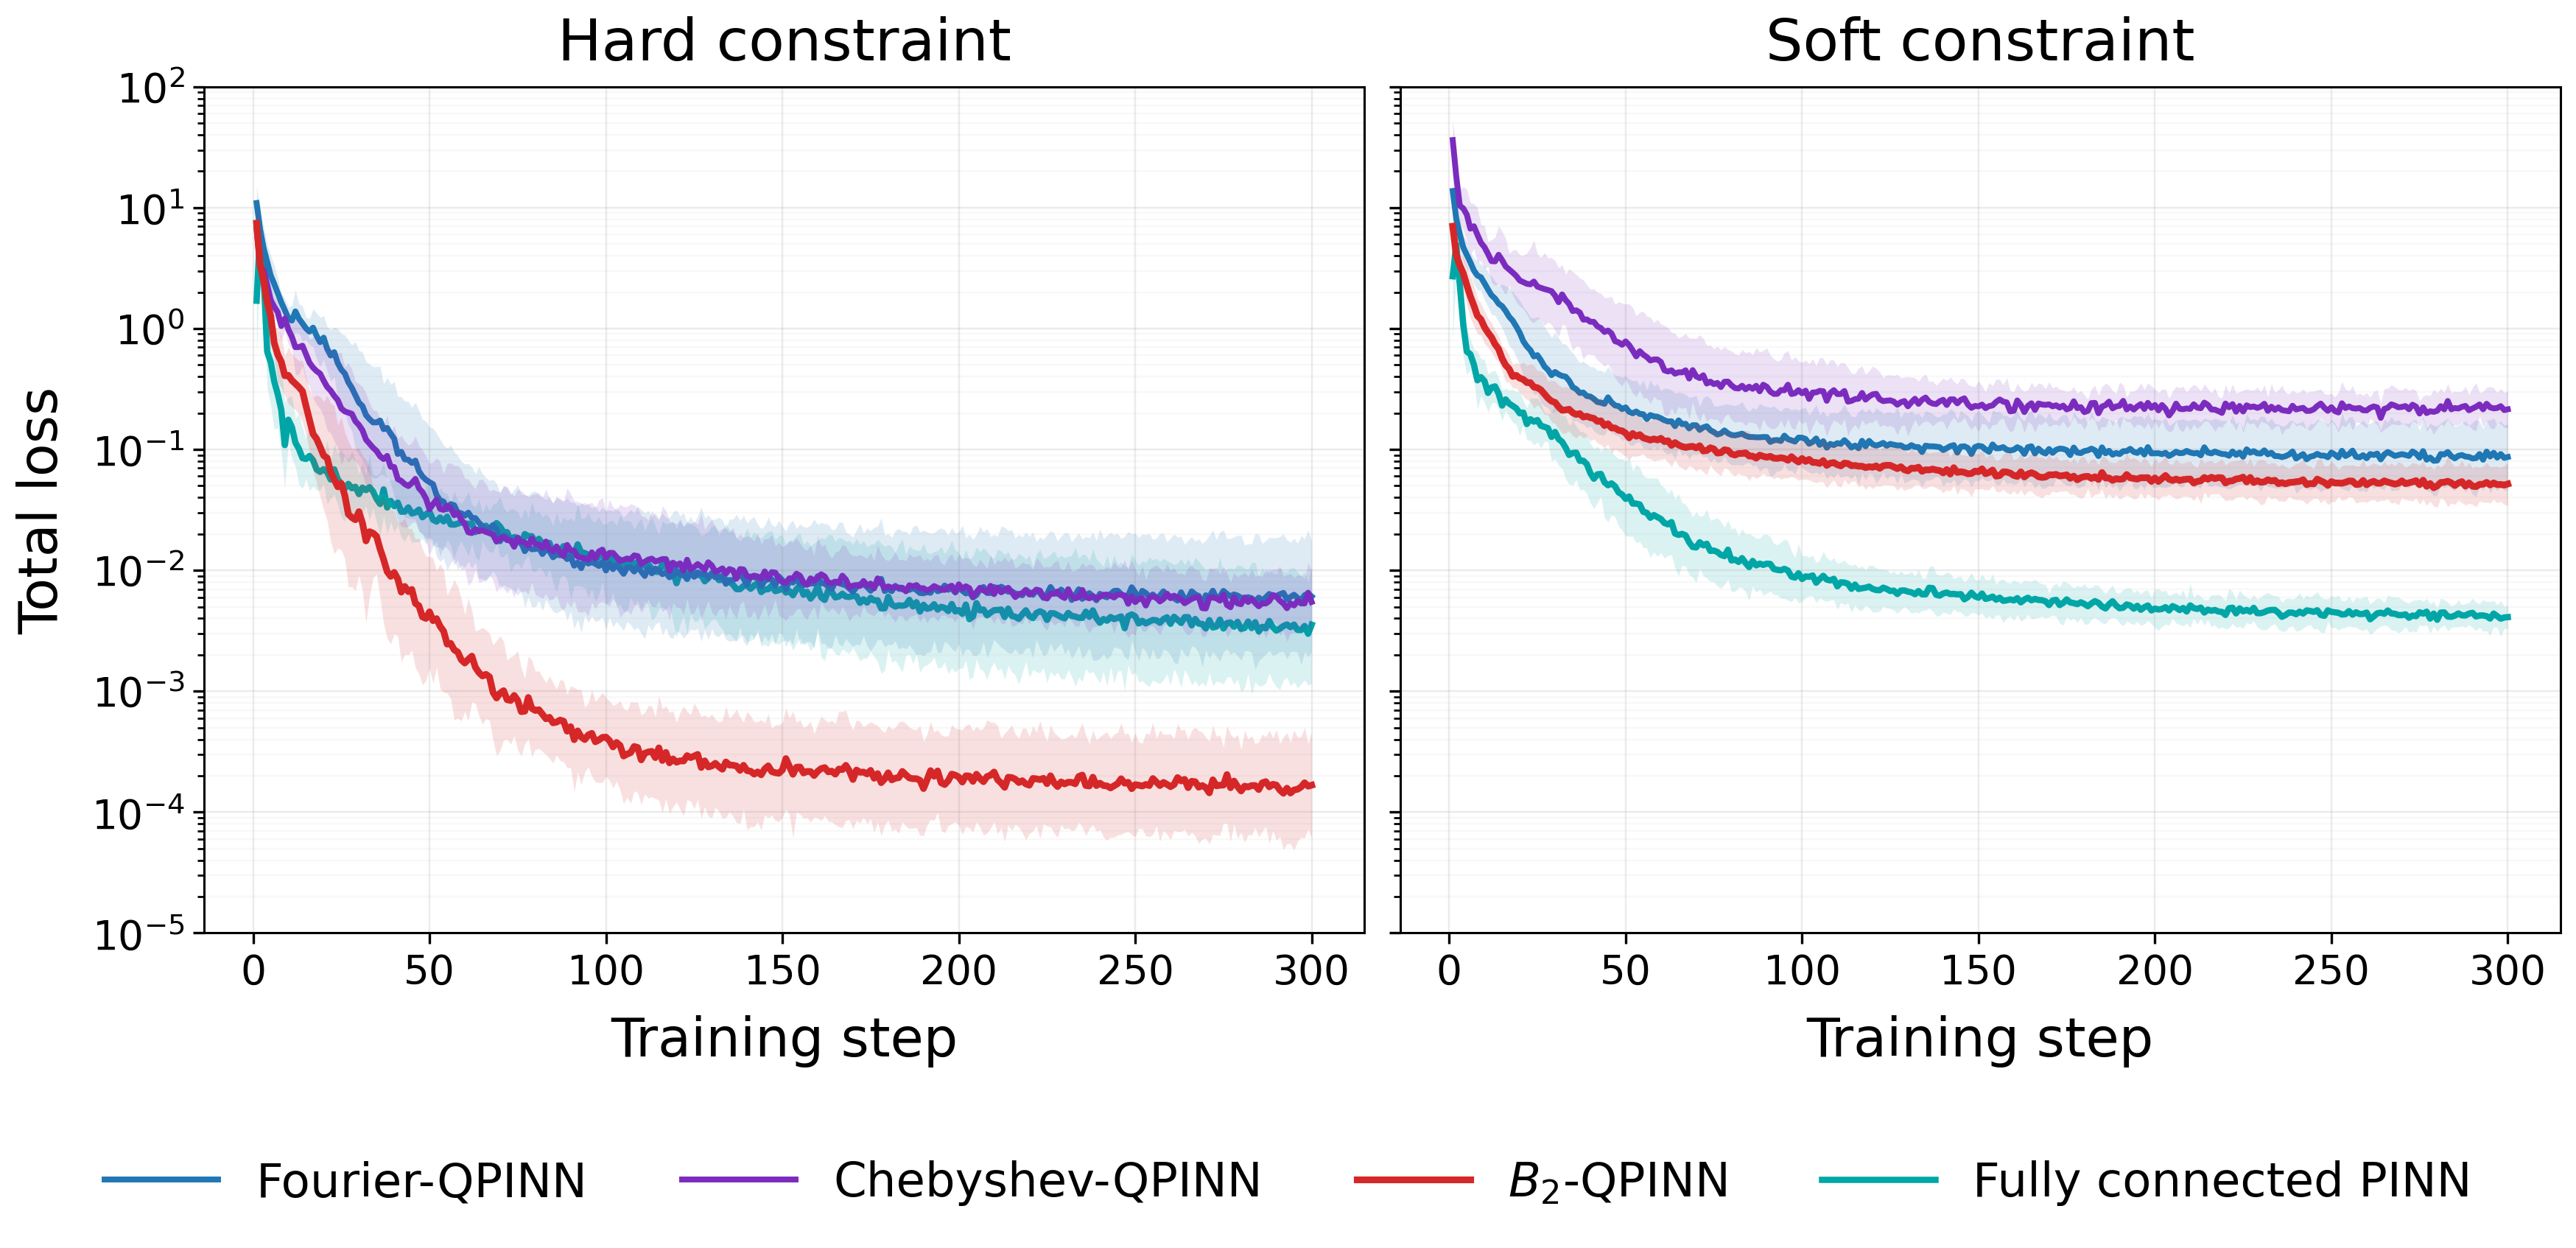

saved side-by-side hard/soft loss comparison: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\qpinn_boundary_constraint_loss_comparison_side_by_side.png


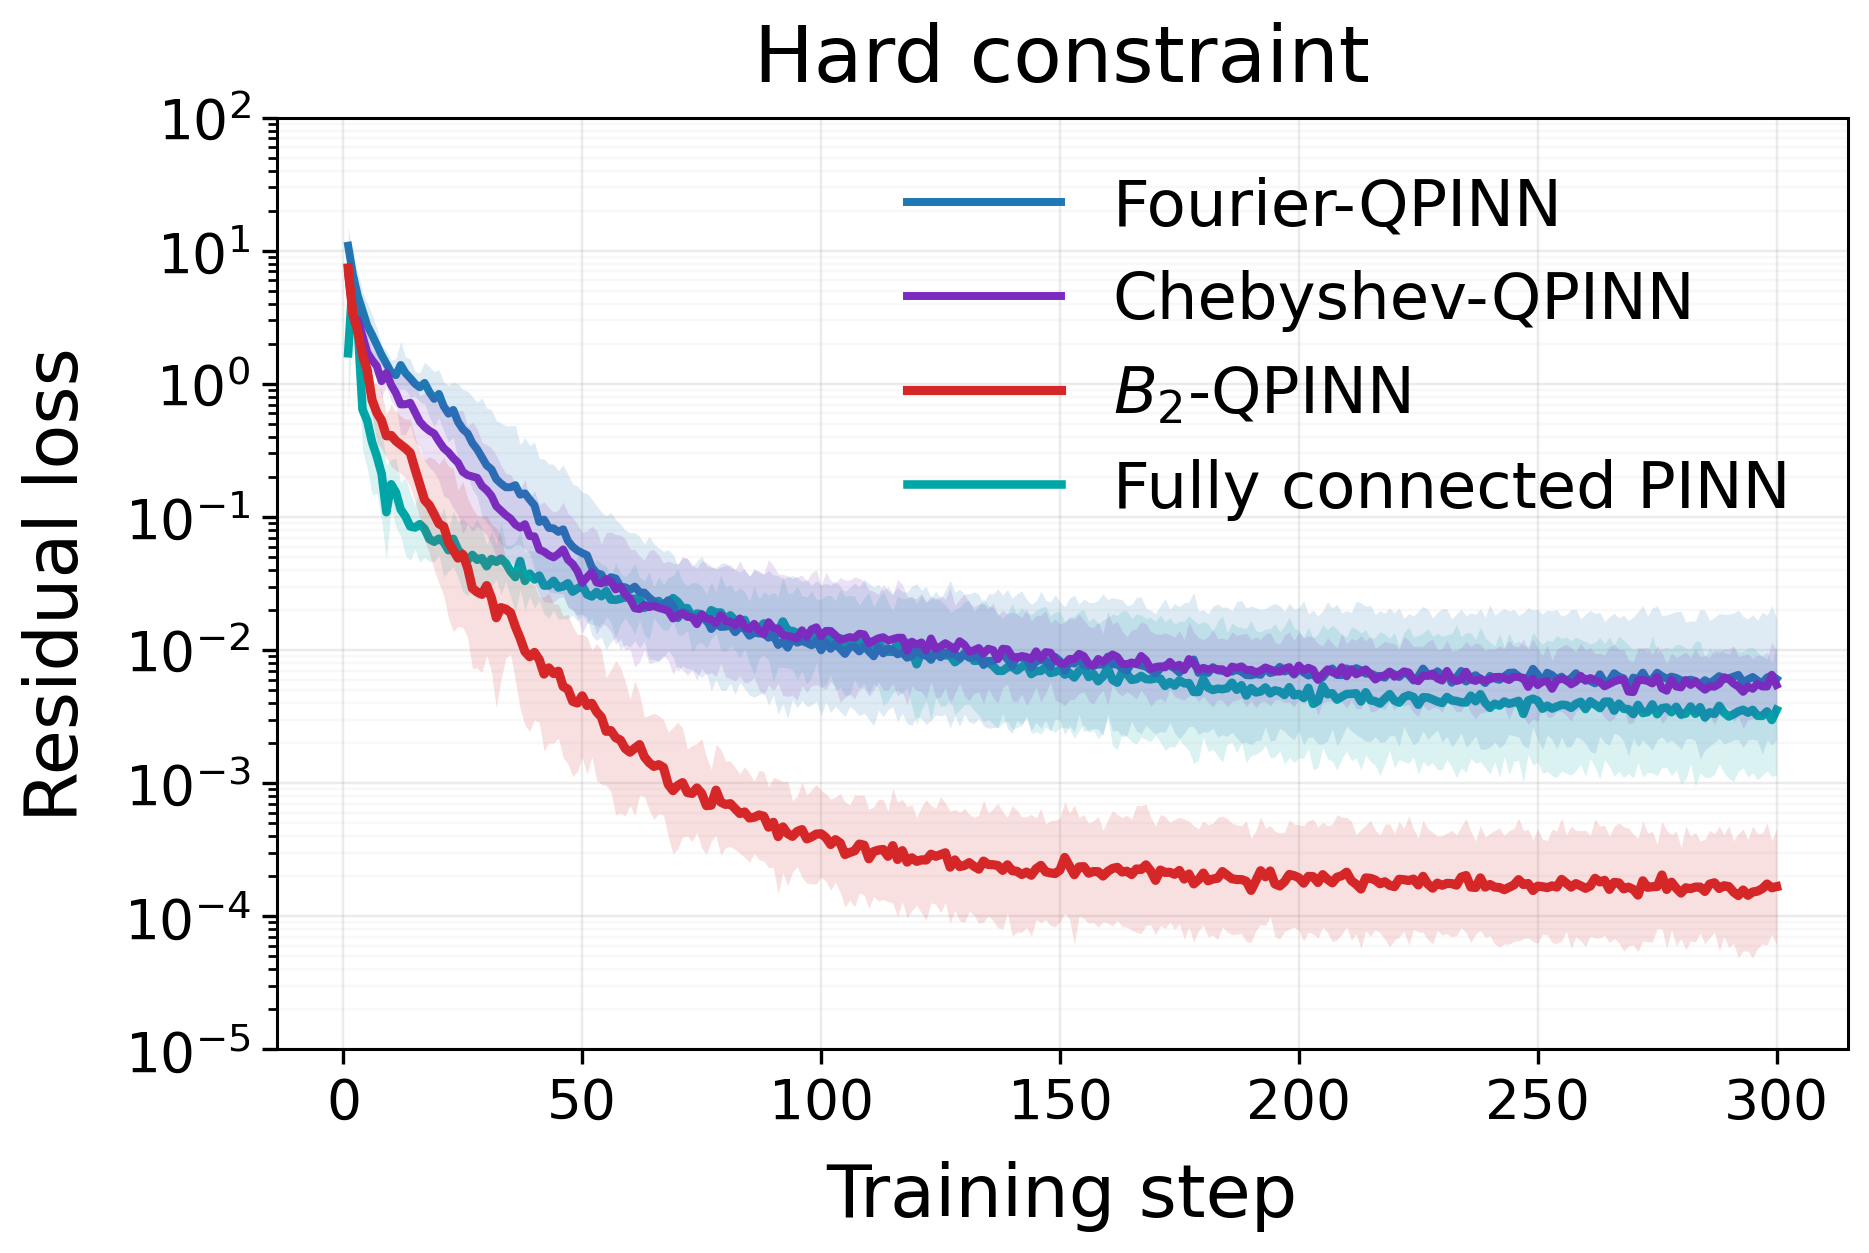

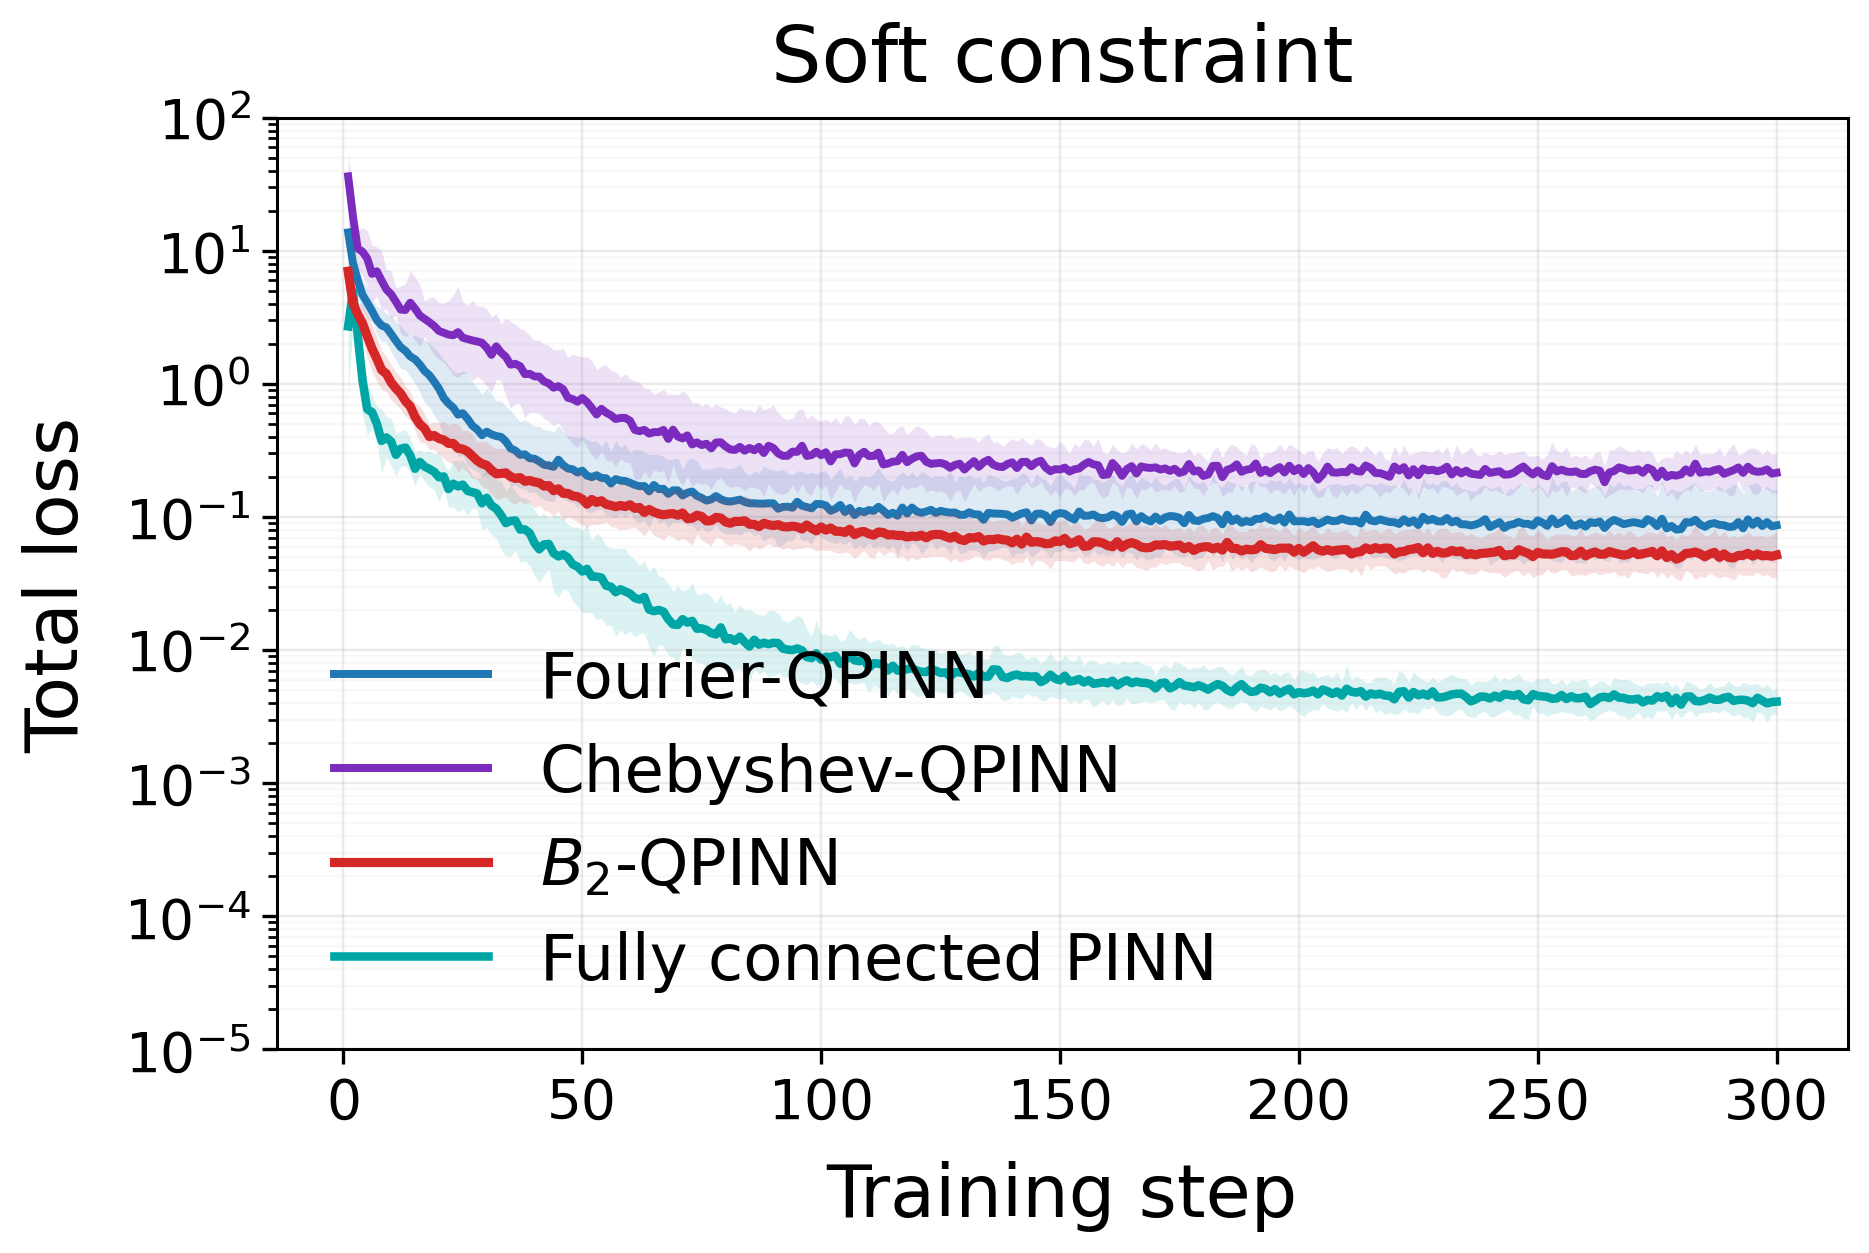

saved Hard constraint single-panel loss comparison: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\qpinn_boundary_hard_constraint_residual_loss.png
saved Soft constraint single-panel loss comparison: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\qpinn_boundary_soft_constraint_total_loss.png


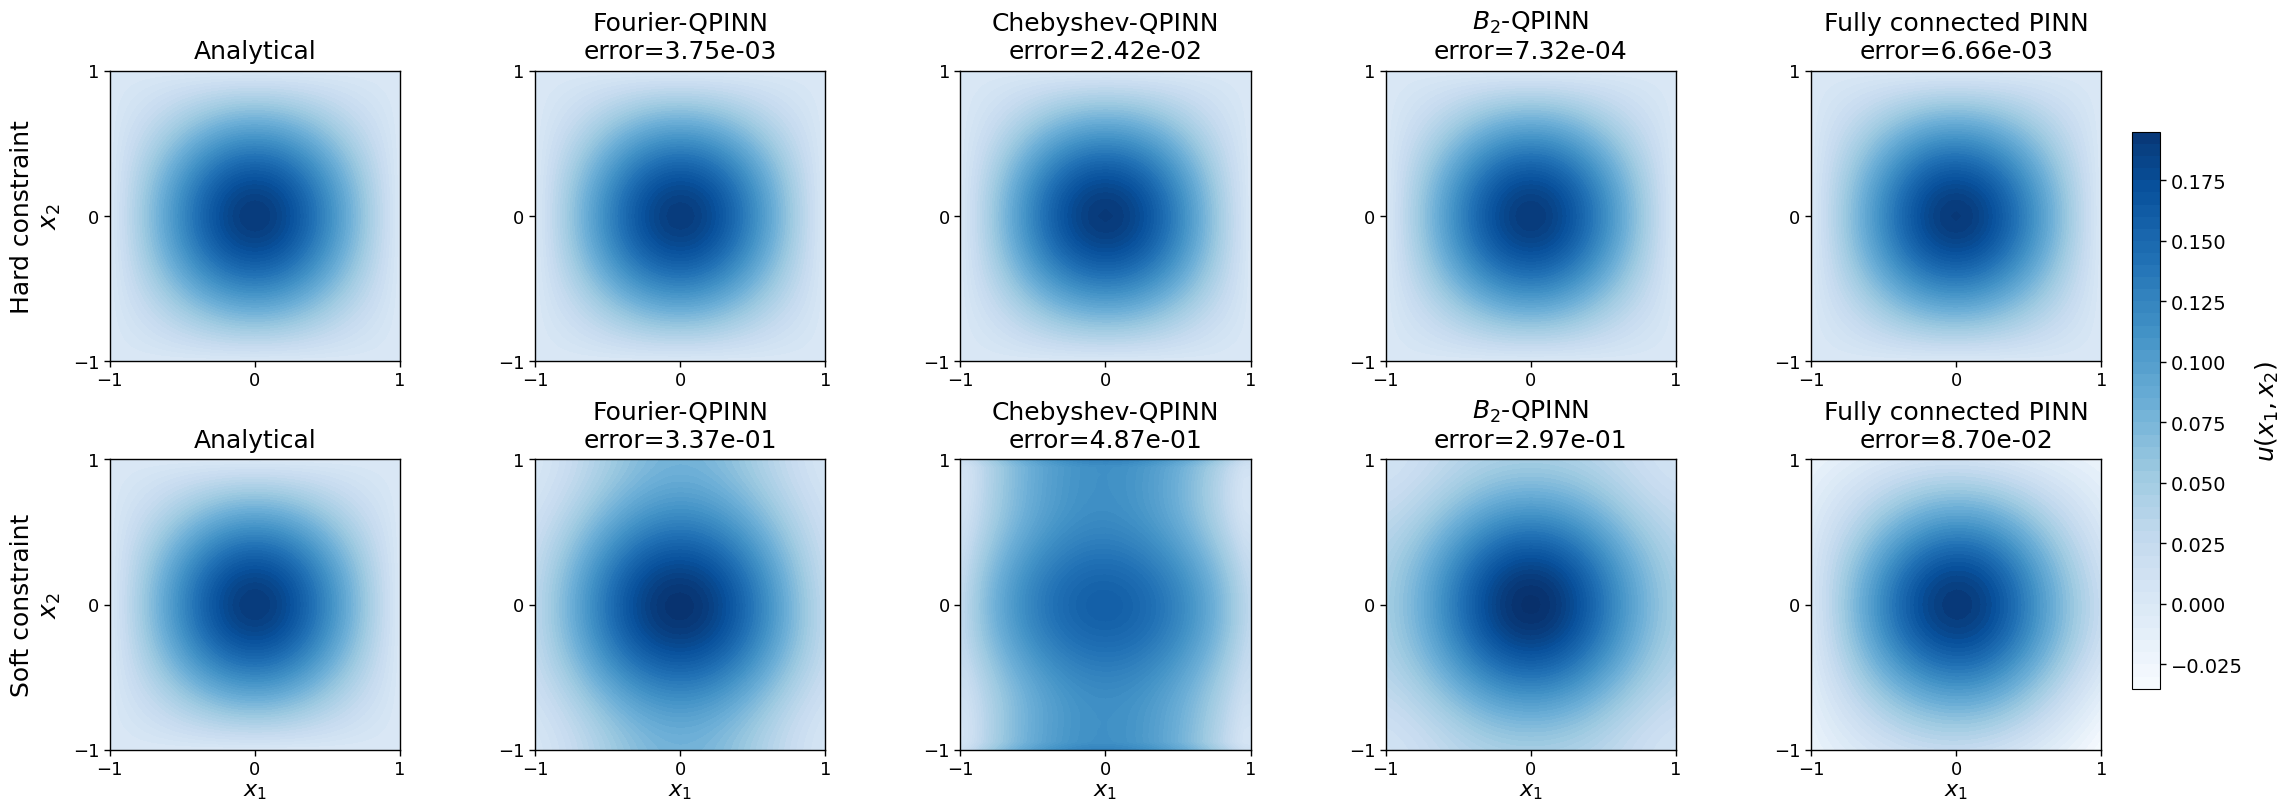

saved combined QPINN/PINN solution comparison: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\qpinn_boundary_constraint_solution_comparison_combined.png


In [12]:
from pathlib import Path
import sys
import numpy as np
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


QPINN_DISPLAY_LABELS = {
    "Ordinary QFM": "Fourier-QPINN",
    "Cheb-QFM": "Chebyshev-QPINN",
    "$B_2$-QCM": "$B_2$-QPINN",
}
QPINN_MODEL_SLUGS = {
    "Ordinary QFM": "ordinary_qfm",
    "Cheb-QFM": "cheb_qfm",
    "$B_2$-QCM": "b2_qcm",
}
PINN_DISPLAY_LABEL = "Fully connected PINN"
PINN_MODEL_SLUG = "fc_pinn"
PINN_CONSTRAINT_SLUGS = {"Hard constraint": "hard", "Soft constraint": "soft"}
PINN_LABELS = ("Hard constraint", "Soft constraint")
PINN_COLORS = {
    "Fourier-QPINN": "#1f77b4",
    "Chebyshev-QPINN": "#7b2cbf",
    "$B_2$-QPINN": "#d62728",
    PINN_DISPLAY_LABEL: "#00A6A6",
}


def pinn_locate_comparison_data_paths() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()
    candidates = []
    if "FIGURE_DIR" in globals():
        candidates.append(Path(FIGURE_DIR))
    candidates.extend([cwd / "Paper_work" / "MSQE" / "figures", cwd / "MSQE" / "figures", cwd])
    for parent in [cwd, *cwd.parents]:
        candidates.extend([parent / "Paper_work" / "MSQE" / "figures", parent / "MSQE" / "figures"])
    seen = set()
    for directory in candidates:
        directory = directory.resolve()
        if directory in seen:
            continue
        seen.add(directory)
        qpinn_path = directory / "qpinn_boundary_constraint_comparison_data.npz"
        pinn_path = directory / "pinn_boundary_constraint_comparison_data.npz"
        if qpinn_path.exists() and pinn_path.exists():
            return qpinn_path, pinn_path
    raise FileNotFoundError("Could not find both QPINN and PINN comparison .npz files")


def pinn_show_or_close_current_figure() -> None:
    if "show_or_close_current_figure" in globals():
        show_or_close_current_figure()
    elif "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()


qpinn_data_path, pinn_data_path = pinn_locate_comparison_data_paths()
qpinn_data = np.load(qpinn_data_path)
pinn_data = np.load(pinn_data_path)
PINN_FIGURE_DIR = Path(globals().get("FIGURE_DIR", qpinn_data_path.parent))
PINN_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


LOSS_YLIM = (1.0e-5, 1.0e2)
LOSS_YTICKS = [1.0e-5, 1.0e-4, 1.0e-3, 1.0e-2, 1.0e-1, 1.0, 1.0e1, 1.0e2]
LOSS_DRAW_ORDER = [
    (PINN_DISPLAY_LABEL, None),
    ("Fourier-QPINN", "Ordinary QFM"),
    ("Chebyshev-QPINN", "Cheb-QFM"),
    ("$B_2$-QPINN", "$B_2$-QCM"),
]
LOSS_LEGEND_ORDER = ["Fourier-QPINN", "Chebyshev-QPINN", "$B_2$-QPINN", PINN_DISPLAY_LABEL]
LOSS_ZORDER = {
    PINN_DISPLAY_LABEL: 2,
    "Fourier-QPINN": 3,
    "Chebyshev-QPINN": 4,
    "$B_2$-QPINN": 6,
}


def plot_loss_lines(ax, constraint_slug: str, metric: str) -> dict[str, object]:
    handles_by_label = {}
    for display_label, qpinn_name in LOSS_DRAW_ORDER:
        if display_label == PINN_DISPLAY_LABEL:
            data = pinn_data
            prefix = f"{constraint_slug}_{PINN_MODEL_SLUG}"
            linewidth = 2.8
        else:
            data = qpinn_data
            prefix = f"{constraint_slug}_{QPINN_MODEL_SLUGS[qpinn_name]}"
            linewidth = 3.0 if display_label == "$B_2$-QPINN" else 2.6

        mean = data[f"{prefix}_{metric}_geo_mean"]
        lower = data[f"{prefix}_{metric}_geo_lower"]
        upper = data[f"{prefix}_{metric}_geo_upper"]
        steps = np.arange(1, len(mean) + 1)
        zorder = LOSS_ZORDER[display_label]
        ax.fill_between(
            steps,
            lower,
            upper,
            color=PINN_COLORS[display_label],
            alpha=0.14,
            linewidth=0,
            zorder=zorder - 0.5,
        )
        (line,) = ax.plot(
            steps,
            mean,
            label=display_label,
            color=PINN_COLORS[display_label],
            linewidth=linewidth,
            zorder=zorder,
        )
        handles_by_label[display_label] = line
    return handles_by_label


def style_loss_axis(ax, title: str, ylabel: str) -> None:
    ax.set_yscale("log")
    ax.set_ylim(*LOSS_YLIM)
    ax.set_yticks(LOSS_YTICKS)
    ax.set_yticklabels([r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$"])
    ax.set_title(title, fontsize=26, pad=12)
    ax.set_xlabel("Training step", fontsize=24, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=24, labelpad=10)
    ax.tick_params(axis="both", which="major", labelsize=18, width=1.1, length=5)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def plot_qpinn_pinn_loss_pair() -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.8), dpi=220, sharex=True, sharey=True)
    configs = {
        "Hard constraint": {"metric": "residual", "ylabel": "Total loss"},
        "Soft constraint": {"metric": "objective", "ylabel": ""},
    }

    legend_handles = None
    for ax, constraint_label in zip(axes, PINN_LABELS):
        constraint_slug = PINN_CONSTRAINT_SLUGS[constraint_label]
        metric = configs[constraint_label]["metric"]
        handles_by_label = plot_loss_lines(ax, constraint_slug, metric)
        if legend_handles is None:
            legend_handles = [handles_by_label[label] for label in LOSS_LEGEND_ORDER]
        style_loss_axis(ax, constraint_label, configs[constraint_label]["ylabel"])

    fig.legend(
        legend_handles,
        LOSS_LEGEND_ORDER,
        frameon=False,
        loc="lower center",
        ncol=4,
        fontsize=21,
        handlelength=2.4,
    )
    fig.tight_layout(rect=(0.0, 0.13, 1.0, 1.0))
    path = PINN_FIGURE_DIR / "qpinn_boundary_constraint_loss_comparison_side_by_side.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    pinn_show_or_close_current_figure()
    return path


def plot_qpinn_pinn_loss_single(constraint_label: str) -> Path:
    constraint_slug = PINN_CONSTRAINT_SLUGS[constraint_label]
    metric = "residual" if constraint_label == "Hard constraint" else "objective"
    ylabel = "Residual loss" if constraint_label == "Hard constraint" else "Total loss"
    filename = (
        "qpinn_boundary_hard_constraint_residual_loss.png"
        if constraint_label == "Hard constraint"
        else "qpinn_boundary_soft_constraint_total_loss.png"
    )

    fig, ax = plt.subplots(figsize=(8.6, 5.8), dpi=220)
    handles_by_label = plot_loss_lines(ax, constraint_slug, metric)
    style_loss_axis(ax, constraint_label, ylabel)
    legend_handles = [handles_by_label[label] for label in LOSS_LEGEND_ORDER]
    ax.legend(
        legend_handles,
        LOSS_LEGEND_ORDER,
        frameon=False,
        loc="best",
        fontsize=21,
        handlelength=2.4,
    )
    fig.tight_layout()
    path = PINN_FIGURE_DIR / filename
    fig.savefig(path, dpi=260, bbox_inches="tight")
    pinn_show_or_close_current_figure()
    return path


side_by_side_loss_path = plot_qpinn_pinn_loss_pair()
print(f"saved side-by-side hard/soft loss comparison: {side_by_side_loss_path}")

single_loss_paths = {constraint_label: plot_qpinn_pinn_loss_single(constraint_label) for constraint_label in PINN_LABELS}
for constraint_label, path in single_loss_paths.items():
    print(f"saved {constraint_label} single-panel loss comparison: {path}")

q_grid_x1 = qpinn_data["grid_x1"]
q_grid_x2 = qpinn_data["grid_x2"]
q_target_grid = qpinn_data["target_grid"]
pinn_predictions = {}
pinn_errors = {}
for constraint_label in PINN_LABELS:
    constraint_slug = PINN_CONSTRAINT_SLUGS[constraint_label]
    prefix = f"{constraint_slug}_{PINN_MODEL_SLUG}"
    pinn_predictions[constraint_label] = pinn_data[f"{prefix}_prediction_grid"]
    pinn_errors[constraint_label] = float(pinn_data[f"{prefix}_error"])

qpin_predictions = {}
qpin_errors = {}
for constraint_label in PINN_LABELS:
    constraint_slug = PINN_CONSTRAINT_SLUGS[constraint_label]
    for qpinn_name in QPINN_DISPLAY_LABELS:
        model_slug = QPINN_MODEL_SLUGS[qpinn_name]
        prefix = f"{constraint_slug}_{model_slug}"
        key = (constraint_label, qpinn_name)
        qpin_predictions[key] = qpinn_data[f"{prefix}_prediction_grid"]
        qpin_errors[key] = float(qpinn_data[f"{prefix}_error"])

combined_values = [q_target_grid, *qpin_predictions.values(), *pinn_predictions.values()]
combined_vmin = min(float(np.min(values)) for values in combined_values)
combined_vmax = max(float(np.max(values)) for values in combined_values)
combined_columns = ["Analytical", *QPINN_DISPLAY_LABELS.keys(), PINN_DISPLAY_LABEL]

fig, axes = plt.subplots(
    len(PINN_LABELS),
    len(combined_columns),
    figsize=(23.0, 8.0),
    constrained_layout=True,
    squeeze=False,
)
assert axes.size == 10
last_image = None
for row, constraint_label in enumerate(PINN_LABELS):
    for col, column_name in enumerate(combined_columns):
        ax = axes[row, col]
        if column_name == "Analytical":
            values = q_target_grid
            title = "Analytical"
        elif column_name == PINN_DISPLAY_LABEL:
            values = pinn_predictions[constraint_label]
            title = f"{PINN_DISPLAY_LABEL}\nerror={pinn_errors[constraint_label]:.2e}"
        else:
            key = (constraint_label, column_name)
            values = qpin_predictions[key]
            display_label = QPINN_DISPLAY_LABELS[column_name]
            title = f"{display_label}\nerror={qpin_errors[key]:.2e}"

        last_image = ax.contourf(
            q_grid_x1,
            q_grid_x2,
            values,
            levels=56,
            cmap="Blues",
            vmin=combined_vmin,
            vmax=combined_vmax,
        )
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=18, pad=9)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.tick_params(axis="both", labelsize=13, width=1.0, length=4)
        if row == len(PINN_LABELS) - 1:
            ax.set_xlabel("$x_1$", fontsize=16, labelpad=2)
        if col == 0:
            ax.set_ylabel(f"{constraint_label}\n$x_2$", fontsize=18, labelpad=7)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

# fig.suptitle("Hard vs soft constraint", fontsize=24)
colorbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.82, pad=0.012)
colorbar.set_label("$u(x_1,x_2)$", fontsize=18, labelpad=8)
colorbar.ax.tick_params(labelsize=14, width=1.0, length=4)
combined_path = PINN_FIGURE_DIR / "qpinn_boundary_constraint_solution_comparison_combined.png"
fig.savefig(combined_path, dpi=240, bbox_inches="tight")
pinn_show_or_close_current_figure()
print(f"saved combined QPINN/PINN solution comparison: {combined_path}")


## Interpretation

This notebook compares the Ordinary QFM, the Kyriienko-style Chebyshev feature map $f_\theta(\arccos x)$, and the exact $B_2$-symmetrized model $(A_{B_2}f_\theta)(x)$.

The Cheb-QFM baseline is intentionally imperfect: it uses the standard substitution $x\mapsto\arccos x$ but does not apply the sign-flip average that removes the non-polynomial terms discussed in the manuscript.  The $B_2$-QCM here uses the exact average over sign flips and coordinate permutations of the physical PDE input $x$.  This keeps the comparison focused: Cheb-QFM tests the conventional Chebyshev encoding baseline, while $B_2$-QCM tests the average-operator symmetry prior.

The hard and soft training-loss plots report geometric mean curves over `N_RUNS` independent runs and shade one geometric standard deviation when multiple runs are available, computed in log space.  The hard plot reports residual loss, while the soft plot reports total loss because that is the quantity optimized by the penalty formulation.  The solution-comparison titles report each representative model's error and prediction range; this makes it explicit whether a panel is actually collapsed near zero or only appears visually compressed by the shared color scale.

The symmetry plot reports three diagnostics.  The model-input sign-flip defect checks the sign-flip action used by each model after its input map.  The coordinate-permutation defect checks exchange symmetry.  The physical $x$ sign-flip defect checks evenness in the original PDE coordinate.